# 2.0 Full EIP-7999 Three-Resource Equilibrium

This notebook combines the independent isoelastic demand curves with the EIP-7999 metering anchors and the induced BAL model to solve a three-resource equilibrium fee vector.

The central mechanism assumptions are:

- a fixed 90M data-gas limit, with data targets of $1/6$, $1/5$, $1/4$, $1/3$, and $1/2$ of the limit;
- execution limits from 250M through 600M in 50M increments, with execution targets at one half of the limit;
- a 75M state-gas target and no state-gas limit;
- the 35-day independent isoelastic estimates centrally, with 21-, 60-, and 75-day estimates as robustness checks;
- the calibrated EIP-8038 + EIP-2780 execution multiplier and EIP-8037 state multiplier used in the Glamsterdam analysis;
- the full-7999 static-data multiplier from notebook 1.11; and
- EIP-8279 runtime BAL induced by state and execution/access activity. The 6,000-block attribution gives a direct-state share $d=0.113937$, a co-produced state-transaction share $c=0.378791$, and a non-state-transaction share $n=0.507272$. The central model sets $\lambda=0$, giving $\omega_{\mathrm{state}}=0.113937$ and $\omega_{\mathrm{execution}}=0.886063$, with the BAL surcharge $\Psi_{\mathrm{BAL}}=1$ and $\rho_A=1$.

The main capacity combinations preserve the observed full-7999 metered data/execution ratio. A separate capacity grid crosses every execution limit with every data target to show what happens when the two capacities are imbalanced. This notebook solves the reserve-free equilibrium. Reserve-dominated equilibria are deferred until a blob-fee path or reserve scenario is specified.

In [1]:
from itertools import product
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import brentq

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from basefee.eip7999_normalized import (
    ResourceFeeConfig,
    compute_base_fee,
    excess_gas_for_base_fee,
)

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
MIN_BASE_FEE_WEI = 1
RESOURCES = ["execution", "data", "state"]

ACCOUNTING_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv"
EXECUTION_REPRICING_DAILY_CSV = DATA_DIR / f"execution_repricing_daily_{DATE_LABEL}.csv"
BAL_RUNTIME_CARD_CSV = DATA_DIR / f"bal_runtime_8279_parameter_card_{DATE_LABEL}.csv"
BAL_CARRIER_PARQUET = DATA_DIR / f"calibration_xatu_bal_runtime_8279_carrier_panel_{DATE_LABEL}.parquet"
BAL_CARRIER_BLOCKS_PARQUET = DATA_DIR / f"calibration_xatu_bal_runtime_8279_carrier_blocks_{DATE_LABEL}.parquet"
BAL_CARRIER_INPUT_CARD_CSV = DATA_DIR / f"calibration_xatu_bal_runtime_8279_carrier_panel_card_{DATE_LABEL}.csv"
ELASTICITY_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
G0_HEADLINE_CSV = DATA_DIR / f"three_way_equilibrium_headline_{DATE_LABEL}.csv"

OUT_CAPACITY_CSV = DATA_DIR / f"full_7999_equilibrium_capacity_card_{DATE_LABEL}.csv"
OUT_ACCOUNTING_CSV = DATA_DIR / f"full_7999_equilibrium_accounting_card_{DATE_LABEL}.csv"
OUT_DATA_BRIDGE_CSV = DATA_DIR / f"full_7999_data_metering_bridge_{DATE_LABEL}.csv"
OUT_BAL_DRIVER_CSV = DATA_DIR / f"full_7999_bal_driver_calibration_{DATE_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"full_7999_equilibrium_results_{DATE_LABEL}.csv"
OUT_HEADLINE_CSV = DATA_DIR / f"full_7999_equilibrium_headline_{DATE_LABEL}.csv"
OUT_WINDOW_CSV = DATA_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.csv"
OUT_GRID_CSV = DATA_DIR / f"full_7999_equilibrium_capacity_grid_{DATE_LABEL}.csv"
OUT_MATCHED_CAPACITY_CSV = DATA_DIR / f"full_7999_empirical_matched_capacity_{DATE_LABEL}.csv"
OUT_DEMAND_ADEQUACY_CSV = DATA_DIR / f"full_7999_execution_demand_adequacy_{DATE_LABEL}.csv"
OUT_BAL_SENSITIVITY_CSV = DATA_DIR / f"full_7999_bal_lambda_beta_sensitivity_{DATE_LABEL}.csv"
OUT_NAMED_BAL_SENSITIVITY_CSV = DATA_DIR / f"full_7999_bal_named_specifications_{DATE_LABEL}.csv"
OUT_BOUNDARY_ENVELOPE_CSV = DATA_DIR / f"full_7999_data_boundary_surcharge_envelope_{DATE_LABEL}.csv"
OUT_CARRIER_PANEL_CSV = DATA_DIR / f"full_7999_bal_carrier_panel_card_{DATE_LABEL}.csv"
GRID_PLOT = PLOTS_DIR / f"full_7999_equilibrium_capacity_grid_{DATE_LABEL}.png"
BOUNDARY_PLOT = PLOTS_DIR / f"full_7999_data_equilibrium_boundary_{DATE_LABEL}.png"
WINDOW_PLOT = PLOTS_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.png"
BAL_SENSITIVITY_PLOT = PLOTS_DIR / f"full_7999_bal_lambda_beta_sensitivity_{DATE_LABEL}.png"
BAL_ALLOCATION_PLOT = PLOTS_DIR / f"full_7999_bal_allocation_sensitivity_{DATE_LABEL}.png"
BAL_SURCHARGE_PLOT = PLOTS_DIR / f"full_7999_bal_surcharge_sensitivity_{DATE_LABEL}.png"
BAL_CAPACITY_EFFECTS_PLOT = PLOTS_DIR / f"full_7999_bal_capacity_grid_effects_{DATE_LABEL}.png"



## Capacity design

The 90M data-gas limit is a scenario input stated in protocol-metered gas. It is not a physical payload limit. In particular, EIP-8279 runtime bytes are transaction-local meter entries and need not equal the final BAL RLP bytes propagated with the block.

The data target is varied from one sixth to one half of the 90M metered limit. Execution has a separate 250M--600M limit sweep, with its target fixed at one half of each limit. State has a 75M target and no hard limit. A physical propagation constraint would require a separate mapping from metered static data and runtime BAL to bytes transmitted on the network.

In [2]:
EXECUTION_LIMITS = [value * 1_000_000 for value in range(250, 601, 50)]
DATA_GAS_LIMIT = 90_000_000
DATA_TARGET_DENOMINATORS = [6, 5, 4, 3, 2]
STATE_TARGET = 75_000_000
EXECUTION_TARGET_RATIO = 2
DATA_GAS_PER_BYTE = 16
AUTHORIZATION_BAL_STATIC_BYTES = 51
BAL_LAMBDA_SENSITIVITY = [0.0, 0.5, 1.0]
BAL_BETA_SENSITIVITY = [0.0, 0.12, 0.23, 0.335]
REPRESENTATIVE_SURCHARGE_LAMBDA = 0.0
REPRESENTATIVE_SURCHARGE_BETA = 0.335
# Appendix C isolates elasticity uncertainty, so it holds the BAL specification at the
# no-response benchmark: Psi_BAL == 1 keeps the transaction-cost denominator (which moves
# with each window's execution and state fees) out of the window comparison.
WINDOW_SENSITIVITY_LAMBDA = 0.0
WINDOW_SENSITIVITY_BETA = 0.0

capacity_card = pd.DataFrame([{
    'data_gas_limit': DATA_GAS_LIMIT,
    'data_target_denominators': ','.join(map(str, DATA_TARGET_DENOMINATORS)),
    'execution_gas_limit_min': min(EXECUTION_LIMITS),
    'execution_gas_limit_max': max(EXECUTION_LIMITS),
    'execution_limit_step': 50_000_000,
    'execution_target_ratio': EXECUTION_TARGET_RATIO,
    'state_gas_target': STATE_TARGET,
    'bal_lambda_sensitivity': ','.join(f'{value:g}' for value in BAL_LAMBDA_SENSITIVITY),
    'bal_surcharge_beta_sensitivity': ','.join(f'{value:g}' for value in BAL_BETA_SENSITIVITY),
    'representative_surcharge_lambda': REPRESENTATIVE_SURCHARGE_LAMBDA,
    'representative_surcharge_beta': REPRESENTATIVE_SURCHARGE_BETA,
    'data_limit_interpretation': (
        'protocol-metered data gas scenario input; not physical payload bytes'
    ),
}])
capacity_card.to_csv(OUT_CAPACITY_CSV, index=False)
display(capacity_card.T)

,0
data_gas_limit,90000000
data_target_denominators,"6,5,4,3,2"
execution_gas_limit_min,250000000
execution_gas_limit_max,600000000
execution_limit_step,50000000
execution_target_ratio,2
state_gas_target,75000000
bal_lambda_sensitivity,"0,0.5,1"
bal_surcharge_beta_sensitivity,"0,0.12,0.23,0.335"
representative_surcharge_lambda,0.000000


## 120-Day Demand And Metering Anchor

The demand elasticities were estimated using three historical gas-equivalent quantities. To transport those curves into 7999, the same physical activity is converted into each candidate resource's gas units.

For each resource, let $q_i^0$ be its historical gas-equivalent quantity and let $m_i$ convert that quantity into 7999 gas. The metered anchor is $g_i^0=m_iq_i^0$. A reference 7999 fee of $p_i^0=b_{\mathrm{ref}}/m_i$ preserves the historical effective price of that activity.

The [current EIP-7999 draft](https://eips.ethereum.org/EIPS/eip-7999) removes the EIP-7623 floor but retains calldata tokens, equivalent to 4 gas per zero byte and 16 per nonzero byte. This project's broader 8131/8279-style bandwidth scenario, specified in the [demand-model plan](../markdowns/demand_model_plan.md), instead meters every encoded byte at 16 gas and adds access-list content, 108-byte authorization tuples, EIP-8279's additional 51 static BAL bytes per authorization, blob hashes, and runtime BAL bytes. The accounting bridge below reports both definitions so that the extension is not mistaken for the base EIP.

The static-data bridge uses exact Xatu calldata and blob-hash counts plus the existing sampled access-list and authorization-list calibrations. It does not make new RPC calls. BAL bytes are excluded from this metering multiplier because they are not independently demanded data. Their priced anchor is the EIP-8279 runtime counter estimated in notebook 1.11; the equilibrium adds that anchor as induced output of execution/access and state activity.

In [3]:
accounting = pd.read_csv(ACCOUNTING_PANEL_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[
    ["date", "data_gas_current", "eip7623_data_uplift_proxy"]
]
execution_repricing = pd.read_csv(EXECUTION_REPRICING_DAILY_CSV)[[
    "date", "execution_current", "execution_8038_2780_refund_corrected",
]]
accounting = accounting.merge(current_data, on="date", how="left", validate="one_to_one")
accounting = accounting.merge(
    execution_repricing, on="date", how="left", validate="one_to_one"
)
required = [
    "data_gas_current", "eip7623_data_uplift_proxy", "execution_current",
    "execution_8038_2780_refund_corrected",
]
if accounting[required].isna().any().any():
    raise ValueError("A data or execution repricing input is missing")
if not np.allclose(
    accounting["data_gas_current"],
    accounting["standard_calldata_gas"] + accounting["eip7623_data_uplift_proxy"],
):
    raise ValueError("Current data gas does not reconcile to standard calldata gas plus EIP-7623 uplift")

blocks = float(accounting["block_count"].sum())
BASE_FEE_REF = float(accounting["median_base_fee_per_gas"].median())
current_data_total = float(accounting["data_gas_current"].sum())
current_state_total = float(accounting["current_state_creation_gas_calibrated"].sum())
current_execution_total = float(
    accounting["current_gas_used"].sum() - current_data_total - current_state_total
)
if not np.allclose(accounting["execution_current"].sum(), current_execution_total, rtol=1e-10, atol=1):
    raise ValueError("Execution repricing denominator does not match the three-resource anchor")

execution_7999_total = float(accounting["execution_8038_2780_refund_corrected"].sum())
data_base_7999_total = float(accounting["standard_calldata_gas"].sum())
data_flat16_calldata_total = float(16 * accounting["calldata_bytes"].sum())
data_blob_hash_total = float(16 * accounting["blob_versioned_hash_bytes"].sum())
data_access_list_total = float(16 * accounting["cal_tx_access_list_bytes"].sum())
data_authorization_tuple_total = float(
    DATA_GAS_PER_BYTE * accounting["cal_authorization_tuple_8131_bytes"].sum()
)
data_authorization_bal_static_total = float(
    DATA_GAS_PER_BYTE * AUTHORIZATION_BAL_STATIC_BYTES
    * (accounting["cal_authorization_tuple_count_per_block"]
       * accounting["block_count"]).sum()
)
data_authorization_total = (
    data_authorization_tuple_total + data_authorization_bal_static_total
)
data_7999_no_bal_total = (
    data_flat16_calldata_total + data_blob_hash_total
    + data_access_list_total + data_authorization_total
)
if not np.isclose(
    data_7999_no_bal_total - data_authorization_bal_static_total,
    accounting["bandwidth_gas_16_calibrated_no_bal"].sum(),
):
    raise ValueError("No-BAL bandwidth components do not reconcile")
bal_runtime_card = pd.read_csv(BAL_RUNTIME_CARD_CSV)
if len(bal_runtime_card) != 1:
    raise ValueError("EIP-8279 runtime BAL parameter card must contain one row")
bal_runtime = bal_runtime_card.iloc[0]
bal_7999_gas_per_block = float(bal_runtime["bal_runtime_data_gas_per_block_at_16"])
bal_7999_total = bal_7999_gas_per_block * blocks
data_7999_with_bal_total = data_7999_no_bal_total + bal_7999_total
state_7999_total = float(accounting["state_gas_8037_calibrated"].sum())
BAL_EXECUTION_GAS_RATIO = bal_7999_total / current_execution_total
BAL_BYTES_PER_MILLION_EXECUTION_GAS = BAL_EXECUTION_GAS_RATIO / DATA_GAS_PER_BYTE * 1_000_000

BAL_DIRECT_STATE_WEIGHT = float(bal_runtime["state_linked_runtime_weight_8279"])
BAL_COPRODUCED_RUNTIME_WEIGHT = float(
    bal_runtime["coproduced_state_transaction_runtime_weight_8279"]
)
BAL_NONSTATE_RUNTIME_WEIGHT = float(bal_runtime["nonstate_transaction_runtime_weight_8279"])
BAL_COPRODUCED_STATE_ALLOCATION = 0.0
BAL_STATE_RUNTIME_WEIGHT = float(bal_runtime["central_effective_state_weight"])
BAL_EXECUTION_RUNTIME_WEIGHT = float(bal_runtime["central_effective_execution_weight"])
BAL_COST_WEIGHTED_LAMBDA = float(bal_runtime["cost_weighted_coproduced_lambda"])
BAL_COST_WEIGHTED_STATE_WEIGHT = float(bal_runtime["illustrative_cost_weighted_state_weight"])
if not np.isclose(
    BAL_DIRECT_STATE_WEIGHT + BAL_COPRODUCED_RUNTIME_WEIGHT + BAL_NONSTATE_RUNTIME_WEIGHT, 1
):
    raise ValueError("Three-way runtime BAL shares do not sum to one")
expected_state_weight = (
    BAL_DIRECT_STATE_WEIGHT
    + BAL_COPRODUCED_STATE_ALLOCATION * BAL_COPRODUCED_RUNTIME_WEIGHT
)
if not np.isclose(BAL_STATE_RUNTIME_WEIGHT, expected_state_weight):
    raise ValueError("Central BAL state weight does not match the lambda allocation")
if not np.isclose(BAL_STATE_RUNTIME_WEIGHT + BAL_EXECUTION_RUNTIME_WEIGHT, 1):
    raise ValueError("Two-way runtime BAL weights do not sum to one")
BAL_ACCESS_RHO = float(bal_runtime["central_rho_access_execution_proxy"])
# Central specification: no BAL surcharge feedback (Psi_BAL = 1), i.e. beta = 0.
BAL_SURCHARGE_BETA_CENTRAL = 0.0
bal_driver_card = pd.DataFrame([{
    "anchor_days": len(accounting),
    "anchor_blocks": blocks,
    "bal_gas_per_block": bal_7999_total / blocks,
    "historical_execution_gas_per_block": current_execution_total / blocks,
    "bal_gas_per_historical_execution_gas": BAL_EXECUTION_GAS_RATIO,
    "bal_bytes_per_million_historical_execution_gas": BAL_BYTES_PER_MILLION_EXECUTION_GAS,
    "parent_driver": "execution quantity as access proxy plus state-linked runtime creation",
    "bal_direct_state_weight": BAL_DIRECT_STATE_WEIGHT,
    "bal_coproduced_state_transaction_weight": BAL_COPRODUCED_RUNTIME_WEIGHT,
    "bal_nonstate_transaction_weight": BAL_NONSTATE_RUNTIME_WEIGHT,
    "bal_coproduced_state_allocation_lambda": BAL_COPRODUCED_STATE_ALLOCATION,
    "bal_state_runtime_weight": BAL_STATE_RUNTIME_WEIGHT,
    "bal_execution_runtime_weight": BAL_EXECUTION_RUNTIME_WEIGHT,
    "bal_cost_weighted_lambda_diagnostic": BAL_COST_WEIGHTED_LAMBDA,
    "bal_cost_weighted_state_weight_diagnostic": BAL_COST_WEIGHTED_STATE_WEIGHT,
    "bal_surcharge_beta_central": BAL_SURCHARGE_BETA_CENTRAL,
    "rho_access_execution_proxy": BAL_ACCESS_RHO,
    "bal_runtime_anchor_blocks": int(bal_runtime["runtime_anchor_blocks"]),
    "state_coupling_status": "central lambda=0: direct-state bytes follow state creation; co-produced and nonstate bytes use access proxy",
}])
bal_driver_card.to_csv(OUT_BAL_DRIVER_CSV, index=False)
display(bal_driver_card.T)

bridge_specs = [
    ("current_eip7623", "current 4/16 calldata plus EIP-7623 floor uplift", current_data_total),
    ("base_eip7999_tx_data", "floor removed; calldata remains 4/16", data_base_7999_total),
    ("flat16_calldata", "project extension: all calldata bytes at 16 gas", data_flat16_calldata_total),
    ("plus_access_lists", "plus sampled fixed access-list content bytes", data_flat16_calldata_total + data_access_list_total),
    ("plus_authorizations", "plus 108-byte authorization tuples and their 51-byte static BAL entries", data_flat16_calldata_total + data_access_list_total + data_authorization_total),
    ("plus_blob_hashes_no_runtime_bal", "plus exact 32-byte blob versioned hashes; static anchor", data_7999_no_bal_total),
    ("plus_runtime_metered_bal", "plus calibrated EIP-8279 runtime BAL gas; reconciliation only", data_7999_with_bal_total),
]
data_bridge = pd.DataFrame(bridge_specs, columns=["scenario", "definition", "total_data_gas"])
data_bridge["data_gas_per_block"] = data_bridge["total_data_gas"] / blocks
data_bridge["multiplier_vs_current_eip7623"] = data_bridge["total_data_gas"] / current_data_total
data_bridge["incremental_gas_per_block"] = data_bridge["total_data_gas"].diff() / blocks
data_bridge["static_anchor_no_bal"] = data_bridge["scenario"].eq("plus_blob_hashes_no_runtime_bal")
data_bridge.to_csv(OUT_DATA_BRIDGE_CSV, index=False)
display(data_bridge)

ANCHOR_QUANTITIES = {
    "execution": current_execution_total / blocks,
    "data": current_data_total / blocks,
    "state": current_state_total / blocks,
}
METERING_MULTIPLIERS = {
    "execution": execution_7999_total / current_execution_total,
    "data": data_7999_no_bal_total / current_data_total,
    "state": state_7999_total / current_state_total,
}
ANCHOR_METERED_GAS = {
    name: ANCHOR_QUANTITIES[name] * METERING_MULTIPLIERS[name]
    for name in RESOURCES
}
REFERENCE_FEES_WEI = {
    name: BASE_FEE_REF / METERING_MULTIPLIERS[name]
    for name in RESOURCES
}

accounting_card = pd.DataFrame([{
    "start_date": accounting["date"].min(),
    "end_date": accounting["date"].max(),
    "days": len(accounting),
    "blocks": blocks,
    "historical_base_fee_ref_gwei": BASE_FEE_REF / GWEI,
    "execution_historical_quantity_per_block": ANCHOR_QUANTITIES["execution"],
    "data_historical_quantity_per_block": ANCHOR_QUANTITIES["data"],
    "state_historical_quantity_per_block": ANCHOR_QUANTITIES["state"],
    "execution_7999_gas_per_block": ANCHOR_METERED_GAS["execution"],
    "data_base_eip7999_4_16_per_block": data_base_7999_total / blocks,
    "data_flat16_calldata_per_block": data_flat16_calldata_total / blocks,
    "data_blob_hash_gas_per_block": data_blob_hash_total / blocks,
    "data_access_list_gas_per_block": data_access_list_total / blocks,
    "data_authorization_tuple_gas_per_block": data_authorization_tuple_total / blocks,
    "data_authorization_bal_static_gas_per_block": data_authorization_bal_static_total / blocks,
    "data_authorization_gas_per_block": data_authorization_total / blocks,
    "data_7999_gas_no_bal_per_block": data_7999_no_bal_total / blocks,
    "bal_7999_gas_per_block": bal_7999_total / blocks,
    "data_7999_gas_with_bal_per_block": data_7999_with_bal_total / blocks,
    "state_7999_gas_per_block": ANCHOR_METERED_GAS["state"],
    "execution_metering_multiplier": METERING_MULTIPLIERS["execution"],
    "data_metering_multiplier_no_bal": METERING_MULTIPLIERS["data"],
    "data_metering_multiplier_with_bal": data_7999_with_bal_total / current_data_total,
    "state_metering_multiplier": METERING_MULTIPLIERS["state"],
    "bal_share_of_data_gas_with_bal": bal_7999_total / data_7999_with_bal_total,
    "bal_gas_per_historical_execution_gas": BAL_EXECUTION_GAS_RATIO,
    "bal_bytes_per_million_historical_execution_gas": BAL_BYTES_PER_MILLION_EXECUTION_GAS,
    "bal_direct_state_weight": BAL_DIRECT_STATE_WEIGHT,
    "bal_coproduced_state_transaction_weight": BAL_COPRODUCED_RUNTIME_WEIGHT,
    "bal_nonstate_transaction_weight": BAL_NONSTATE_RUNTIME_WEIGHT,
    "bal_coproduced_state_allocation_lambda": BAL_COPRODUCED_STATE_ALLOCATION,
    "bal_state_runtime_weight": BAL_STATE_RUNTIME_WEIGHT,
    "bal_execution_runtime_weight": BAL_EXECUTION_RUNTIME_WEIGHT,
    "bal_surcharge_beta_central": BAL_SURCHARGE_BETA_CENTRAL,
    "bal_access_rho_central": BAL_ACCESS_RHO,
    "bal_runtime_anchor_blocks": int(bal_runtime["runtime_anchor_blocks"]),
    "execution_reference_fee_gwei": REFERENCE_FEES_WEI["execution"] / GWEI,
    "data_reference_fee_gwei": REFERENCE_FEES_WEI["data"] / GWEI,
    "state_reference_fee_gwei": REFERENCE_FEES_WEI["state"] / GWEI,
}])
accounting_card.to_csv(OUT_ACCOUNTING_CSV, index=False)
display(accounting_card.T)

# Preserve the observed full-7999 metered resource mix along the main comparison.
EMPIRICAL_DATA_EXECUTION_TARGET_RATIO = (
    data_7999_with_bal_total / execution_7999_total
)

matched_capacity_rows = []
for denominator in DATA_TARGET_DENOMINATORS:
    data_target = int(DATA_GAS_LIMIT // denominator)
    matched_execution_target = data_target / EMPIRICAL_DATA_EXECUTION_TARGET_RATIO
    matched_execution_limit = int(round(EXECUTION_TARGET_RATIO * matched_execution_target))
    matched_capacity_rows.append({
        'data_target_denominator': denominator,
        'data_target_ratio': 1 / denominator,
        'data_gas_limit': DATA_GAS_LIMIT,
        'data_gas_target': data_target,
        'empirical_data_execution_target_ratio': EMPIRICAL_DATA_EXECUTION_TARGET_RATIO,
        'matched_execution_gas_target': matched_execution_limit // EXECUTION_TARGET_RATIO,
        'matched_execution_gas_limit': matched_execution_limit,
        'within_250m_600m_execution_range': (
            min(EXECUTION_LIMITS) <= matched_execution_limit <= max(EXECUTION_LIMITS)
        ),
    })
matched_capacity_card = pd.DataFrame(matched_capacity_rows)
matched_capacity_card.to_csv(OUT_MATCHED_CAPACITY_CSV, index=False)

accounting_card['empirical_data_execution_target_ratio'] = (
    EMPIRICAL_DATA_EXECUTION_TARGET_RATIO
)
accounting_card.to_csv(OUT_ACCOUNTING_CSV, index=False)
display(matched_capacity_card)


# --- Per-transaction carrier panel for the BAL surcharge -----------------------
# The compact input covers the same 6,000 blocks as the aggregate BAL card.
# Xatu supplies runtime BAL, receipt/state inputs, calldata, and blob hashes;
# full transaction bodies supply access-list and authorization counts.
# Capacity expansion changes the multiplicity of historical-like carriers rather
# than making each transaction's measured BAL footprint proportionally larger.
_carriers = pd.read_parquet(BAL_CARRIER_PARQUET)
_carrier_blocks = pd.read_parquet(BAL_CARRIER_BLOCKS_PARQUET)
_carrier_input_card = pd.read_csv(BAL_CARRIER_INPUT_CARD_CSV)
if len(_carrier_input_card) != 1:
    raise ValueError("The 6,000-block carrier input card must contain one row")
_carrier_input = _carrier_input_card.iloc[0]
if int(_carrier_input["blocks"]) != 6_000:
    raise ValueError("The BAL surcharge requires the complete 6,000-block panel")
if len(_carrier_blocks) != 6_000 or _carrier_blocks["block_number"].duplicated().any():
    raise ValueError("The carrier block panel must contain 6,000 unique blocks")
if not set(_carriers["block_number"]).issubset(set(_carrier_blocks["block_number"])):
    raise ValueError("Carrier transactions occur outside the 6,000-block sample")
if len(_carriers) != int(_carrier_input["carrier_transactions"]):
    raise ValueError("Carrier transaction count does not match the input card")
if not bool(_carrier_input["static_data_detail_complete"]):
    raise ValueError("Carrier static-data charges are incomplete")
if _carriers.duplicated(["block_number", "tx_index", "tx_hash"]).any():
    raise ValueError("Carrier panel contains duplicate transactions")
if not _carriers["static_data_detail_complete"].all():
    raise ValueError("A carrier is missing access-list or authorization data")

CARRIER_BAL_GAS = _carriers["bal_metered_gas_7999"].to_numpy(dtype=float)
CARRIER_BAL_DIRECT_GAS = DATA_GAS_PER_BYTE * _carriers[
    "bal_runtime_bytes_direct_state_8279"].to_numpy(dtype=float)
CARRIER_BAL_COPRODUCED_GAS = DATA_GAS_PER_BYTE * _carriers[
    "bal_runtime_bytes_coproduced_state_txs_8279"].to_numpy(dtype=float)
CARRIER_BAL_NONSTATE_GAS = DATA_GAS_PER_BYTE * _carriers[
    "bal_runtime_bytes_nonstate_txs_8279"].to_numpy(dtype=float)
if not np.allclose(
    CARRIER_BAL_DIRECT_GAS + CARRIER_BAL_COPRODUCED_GAS + CARRIER_BAL_NONSTATE_GAS,
    CARRIER_BAL_GAS,
):
    raise ValueError("Per-transaction runtime BAL components do not sum to total BAL gas")

_carrier_total_bal_gas = CARRIER_BAL_GAS.sum()
# This reconciles the raw 6,000-block carrier sample. The equilibrium BAL
# anchor above is separately weighted by canonical block counts per day.
_expected_total_bal_gas = DATA_GAS_PER_BYTE * float(
    _carrier_input["bal_runtime_bytes_8279"]
)
if not np.isclose(_carrier_total_bal_gas, _expected_total_bal_gas, rtol=0, atol=0):
    raise ValueError("Carrier BAL gas does not match the 6,000-block input card")
_panel_component_shares = {
    "direct": CARRIER_BAL_DIRECT_GAS.sum() / _carrier_total_bal_gas,
    "coproduced": CARRIER_BAL_COPRODUCED_GAS.sum() / _carrier_total_bal_gas,
    "nonstate": CARRIER_BAL_NONSTATE_GAS.sum() / _carrier_total_bal_gas,
}
_expected_component_shares = np.array([
    BAL_DIRECT_STATE_WEIGHT,
    BAL_COPRODUCED_RUNTIME_WEIGHT,
    BAL_NONSTATE_RUNTIME_WEIGHT,
])
if not np.allclose(
    np.array(list(_panel_component_shares.values())),
    _expected_component_shares,
    rtol=1e-10, atol=1e-12,
):
    raise ValueError("Carrier components do not match the 6,000-block BAL card")
CARRIER_WEIGHT_DIRECT = CARRIER_BAL_DIRECT_GAS
CARRIER_WEIGHT_COPRODUCED = CARRIER_BAL_COPRODUCED_GAS
CARRIER_WEIGHT_NONSTATE = CARRIER_BAL_NONSTATE_GAS
CARRIER_STATIC_GAS = _carriers["static_data_gas_7999"].to_numpy(dtype=float)
CARRIER_STATE_GAS = _carriers["state_metered_gas_8037"].to_numpy(dtype=float)
CARRIER_EXECUTION_GAS = _carriers["execution_metered_gas_7999"].to_numpy(dtype=float)


def carrier_scenario_bal_gas(*, lambda_bal, state_ratio, access_ratio):
    """Each carrier's BAL gas after its parent activity scales.

    State-linked bytes follow state activity and access-linked bytes follow the
    execution/access proxy, so a scenario that scales the two differently also
    changes the carrier composition. Summing this over carriers reproduces the
    block-level parent-activity ratio.
    """

    state_component = CARRIER_WEIGHT_DIRECT + lambda_bal * CARRIER_WEIGHT_COPRODUCED
    access_component = (
        CARRIER_WEIGHT_NONSTATE + (1.0 - lambda_bal) * CARRIER_WEIGHT_COPRODUCED
    )
    return state_ratio * state_component + access_ratio * access_component


def bal_surcharge(*, execution_fee_wei, data_fee_wei, state_fee_wei, beta_bal,
                  lambda_bal, state_ratio, access_ratio, scenario_weights=None):
    """One-sided incremental BAL surcharge Psi_BAL in (0, 1].

    Each carrier pays a new charge b_data * g_BAL on top of a bill that already
    contains its execution, state, and complete static-data charges at the
    scenario's own fees. Per-transaction gas quantities stay at their measured
    panel values; responses are averaged over the carrier composition implied by
    the scenario's state and access expansion.
    """

    if beta_bal <= 0:
        return 1.0
    non_bal_bill = (
        execution_fee_wei * CARRIER_EXECUTION_GAS
        + state_fee_wei * CARRIER_STATE_GAS
        + data_fee_wei * CARRIER_STATIC_GAS
    )
    surcharge_ratio = np.divide(
        data_fee_wei * CARRIER_BAL_GAS,
        non_bal_bill,
        out=np.full_like(non_bal_bill, np.inf, dtype=float),
        where=non_bal_bill > 0,
    )
    response = (1.0 + surcharge_ratio) ** (-beta_bal)
    weights = scenario_weights
    if weights is None:
        weights = carrier_scenario_bal_gas(
            lambda_bal=lambda_bal, state_ratio=state_ratio, access_ratio=access_ratio
        )
    return float(np.dot(weights, response) / weights.sum())


def bal_surcharge_asymptote(*, beta_bal, scenario_weights):
    """Limit of Psi_BAL as the data fee tends to infinity.

    For a carrier with positive static data, the incremental BAL charge divided
    by its non-BAL bill tends to g_BAL / g_static. A carrier without static data
    has an infinite limiting surcharge ratio and therefore zero response.
    """

    if beta_bal <= 0:
        return 1.0
    surcharge_ratio_limit = np.divide(
        CARRIER_BAL_GAS,
        CARRIER_STATIC_GAS,
        out=np.full_like(CARRIER_BAL_GAS, np.inf, dtype=float),
        where=CARRIER_STATIC_GAS > 0,
    )
    response_limit = (1.0 + surcharge_ratio_limit) ** (-beta_bal)
    return float(np.dot(scenario_weights, response_limit) / scenario_weights.sum())


carrier_panel_card = pd.DataFrame([{
    "carrier_transactions": int(len(CARRIER_BAL_GAS)),
    "panel_transactions": int(_carrier_input["transactions"]),
    "panel_blocks": int(_carrier_input["blocks"]),
    "carrier_bal_gas_reconciles": bool(np.isclose(
        CARRIER_BAL_GAS.sum(), DATA_GAS_PER_BYTE * _carrier_input["bal_runtime_bytes_8279"]
    )),
    "carrier_bal_to_static_gas_ratio": float(
        CARRIER_BAL_GAS.sum() / CARRIER_STATIC_GAS.sum()
    ),
    "panel_direct_state_share": _panel_component_shares["direct"],
    "panel_coproduced_share": _panel_component_shares["coproduced"],
    "panel_nonstate_share": _panel_component_shares["nonstate"],
    "component_share_source": "same reconciled 6,000-block transaction panel",
    "per_transaction_convention": (
        "measured panel quantities held fixed; capacity expansion carried by the "
        "block-level parent-activity term"
    ),
    "static_gas_definition": "16 gas per calldata, access-list, 108-byte authorization tuple, 51-byte authorization BAL entry, and blob-hash byte",
    "state_gas_definition": "EIP-8037 state bytes times 1,530 CPSB",
    "execution_gas_definition": "EIP-7623/state-deaccounted receipt gas times the execution multiplier",
}])
carrier_panel_card.to_csv(OUT_CARRIER_PANEL_CSV, index=False)
display(carrier_panel_card.T)


,0
anchor_days,120
anchor_blocks,"860,505.000000"
bal_gas_per_block,"1,919,099.891982"
historical_execution_gas_per_block,"23,942,241.363434"
bal_gas_per_historical_execution_gas,0.080155
bal_bytes_per_million_historical_execution_gas,"5,009.712392"
parent_driver,execution quantity as access proxy plus state-...
bal_direct_state_weight,0.113937
bal_coproduced_state_transaction_weight,0.378791
bal_nonstate_transaction_weight,0.507272


,scenario,definition,total_data_gas,data_gas_per_block,multiplier_vs_current_eip7623,incremental_gas_per_block,static_anchor_no_bal
0,current_eip7623,current 4/16 calldata plus EIP-7623 floor uplift,"1,015,873,534,534.000000","1,180,555.063055",1.000000,NaN,False
1,base_eip7999_tx_data,floor removed; calldata remains 4/16,"888,840,106,060.000000","1,032,928.461845",0.874952,"-147,626.601210",False
2,flat16_calldata,project extension: all calldata bytes at 16 gas,"1,728,593,461,888.000000","2,008,812.803979",1.701583,"975,884.342134",False
3,plus_access_lists,plus sampled fixed access-list content bytes,"1,807,694,404,961.515137","2,100,736.666215",1.779448,"91,923.862236",False
4,plus_authorizations,plus 108-byte authorization tuples and their 5...,"1,834,351,066,257.815430","2,131,714.593475",1.805688,"30,977.927259",False
5,plus_blob_hashes_no_runtime_bal,plus exact 32-byte blob versioned hashes; stat...,"1,835,938,020,497.815430","2,133,558.806164",1.807251,"1,844.212689",True
6,plus_runtime_metered_bal,plus calibrated EIP-8279 runtime BAL gas; reco...,"3,487,333,073,047.575684","4,052,658.698145",3.432842,"1,919,099.891982",False


,0
start_date,2026-02-01
end_date,2026-05-31
days,120
blocks,"860,505.000000"
historical_base_fee_ref_gwei,0.106928
execution_historical_quantity_per_block,"23,942,241.363434"
data_historical_quantity_per_block,"1,180,555.063055"
state_historical_quantity_per_block,"5,244,154.703798"
execution_7999_gas_per_block,"36,820,725.629258"
data_base_eip7999_4_16_per_block,"1,032,928.461845"


,data_target_denominator,data_target_ratio,data_gas_limit,data_gas_target,empirical_data_execution_target_ratio,matched_execution_gas_target,matched_execution_gas_limit,within_250m_600m_execution_range
0,6,0.166667,90000000,15000000,0.110065,136283592,272567184,True
1,5,0.200000,90000000,18000000,0.110065,163540310,327080621,True
2,4,0.250000,90000000,22500000,0.110065,204425388,408850776,True
3,3,0.333333,90000000,30000000,0.110065,272567184,545134368,True
4,2,0.500000,90000000,45000000,0.110065,408850776,817701552,False


,0
carrier_transactions,996163
panel_transactions,1899748
panel_blocks,6000
carrier_bal_gas_reconciles,True
carrier_bal_to_static_gas_ratio,0.926496
panel_direct_state_share,0.113937
panel_coproduced_share,0.378791
panel_nonstate_share,0.507272
component_share_source,"same reconciled 6,000-block transaction panel"
per_transaction_convention,measured panel quantities held fixed; capacity...


## Independent Isoelastic Elasticities

Notebook 1.8 recovers separate execution, data, and state elasticities from the clean 2025 gas-limit events. The 35-day estimates are central. All four available window lengths are retained here because the equilibrium fee can be very sensitive when an elasticity is small. No aggregate-plus-softmax result is used in this notebook.

In [4]:
elasticities = pd.read_csv(ELASTICITY_CSV).sort_values("window_days")
WINDOW_DAYS = elasticities["window_days"].astype(int).tolist()
CENTRAL_WINDOW = 35
if CENTRAL_WINDOW not in WINDOW_DAYS:
    raise ValueError("35-day elasticity calibration is missing")
if (elasticities[[f"eps_{name}" for name in RESOURCES]] <= 0).any().any():
    raise ValueError("All independent elasticities must be positive")
display(elasticities[[
    "window_days", "eps_agg", "eps_execution", "eps_data", "eps_state"
]])

,window_days,eps_agg,eps_execution,eps_data,eps_state
0,21,0.194893,0.117067,0.201790,0.478438
1,35,0.169292,0.121160,0.229476,0.334864
2,60,0.127086,0.081668,0.204691,0.279676
3,75,0.119173,0.078511,0.201391,0.253556


## Three-resource equilibrium

Execution and state retain separate isoelastic demand curves. For either independently demanded resource $i$,

$$
g_i(p_i)=g_i^0\left(\frac{p_i}{p_i^0}\right)^{-\epsilon_i},
\qquad
p_i^*=p_i^0\left(\frac{g_i^0}{T_i}\right)^{1/\epsilon_i}.
$$

BAL is induced by the equilibrium execution and state quantities. Let $d$, $c$, and $n$ denote the direct-state, co-produced-access, and non-state-transaction runtime shares. For $\lambda\in[0,1]$,

$$
w_{\mathrm{state}}(\lambda)=d+\lambda c,
\qquad
w_{\mathrm{execution}}(\lambda)=n+(1-\lambda)c.
$$

At fixed execution and state targets, BAL data gas is:

$$
\widetilde B(\lambda)=B_0\left[
w_{\mathrm{state}}(\lambda)\frac{T_S/m_S}{S_0}
+w_{\mathrm{execution}}(\lambda)
\left(\frac{T_E/m_E}{E_0}\right)^{\rho_A}
\right].
$$

BAL bytes carried no historical data charge, so their data fee is treated as an incremental surcharge. The 6,000-block BAL-carrying-transaction panel holds each historical-like transaction's metered quantities fixed while capacity growth changes how frequently its state- and access-linked BAL components appear. Define

$$
R_S=\frac{T_S/m_S}{S_0},
\qquad
R_A=\left(\frac{T_E/m_E}{E_0}\right)^{\rho_A},
$$

and let $g_{d,j}$, $g_{c,j}$, and $g_{n,j}$ be transaction $j$'s direct-state, co-produced, and non-state BAL gas. Its scenario weight is

$$
\widetilde g_{\mathrm{BAL},j}(\lambda)=
R_S\left(g_{d,j}+\lambda g_{c,j}\right)
+R_A\left[g_{n,j}+(1-\lambda)g_{c,j}\right].
$$

For the transaction's measured BAL footprint $g_{\mathrm{BAL},j}=g_{d,j}+g_{c,j}+g_{n,j}$, the surcharge response is averaged with these scenario-specific weights:

$$
\Psi_{\mathrm{BAL}}(b_D)=
\frac{
\sum_j \widetilde g_{\mathrm{BAL},j}(\lambda)
\left(1+\dfrac{b_Dg_{\mathrm{BAL},j}}
{b_Eg_{E,j}+b_Sg_{S,j}+b_Dg_{\mathrm{static},j}}\right)^{-\beta_{\mathrm{BAL}}}
}{
\sum_j \widetilde g_{\mathrm{BAL},j}(\lambda)
},
\qquad 0<\Psi_{\mathrm{BAL}}\le 1.
$$

Here $g_{\mathrm{static},j}$ includes calldata, access-list content, 108-byte authorization tuples, the additional 51 static BAL bytes per authorization required by EIP-8279, and blob-versioned hashes. The fees are the scenario's execution, state, and data fees. The data equilibrium clears static data plus surcharged BAL:

$$
D_{\mathrm{static}}^0r_D^{-\epsilon_D}
+\widetilde B(\lambda)\,\Psi_{\mathrm{BAL}}(b_D)=T_D.
$$

With $\beta_{\mathrm{BAL}}=0$ the surcharge is identically one, and the target-clearing fee stays analytic:

$$
p_D^*=p_D^0
\left(
\frac{g_{\mathrm{static}}^0}{T_D-\widetilde B}
\right)^{1/\epsilon_D},
$$

which exists only when $\widetilde B<T_D$. For $\beta_{\mathrm{BAL}}>0$, static demand tends to zero as the data fee rises. The BAL response approaches a scenario-weighted limit determined by each BAL-carrying transaction's measured BAL-to-static-data ratio; BAL-carrying transactions without static data have a zero limiting response. The notebook evaluates this exact asymptote for the feasibility check and solves the remaining root in log-price space. The central results remain $\lambda=0$ and $\Psi_{\mathrm{BAL}}=1$; the $3\times4$ parameter grid is reported separately.

The notebook reports both the equilibrium fee and the nearest fee representable by the integer fake exponential. It separately flags targets that require an equilibrium fee below the one-wei protocol minimum. Those cases are mathematical extrapolations, not equilibria that the protocol can represent.

In [5]:
def resource_config(resource, execution_limit, data_target):
    if resource == 'execution':
        return ResourceFeeConfig(
            name=resource,
            gas_limit=int(execution_limit),
            gas_target=int(execution_limit // EXECUTION_TARGET_RATIO),
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    if resource == 'data':
        return ResourceFeeConfig(
            name=resource,
            gas_limit=DATA_GAS_LIMIT,
            gas_target=int(data_target),
            min_base_fee=MIN_BASE_FEE_WEI,
            reserve_mode='none',
        )
    if resource == 'state':
        return ResourceFeeConfig(
            name=resource,
            gas_limit=None,
            gas_target=STATE_TARGET,
            normalization_denominator=STATE_TARGET,
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    raise ValueError(resource)


def metered_demand(base_fee_wei, *, anchor_metered_gas, reference_fee_wei, elasticity):
    return anchor_metered_gas * (base_fee_wei / reference_fee_wei) ** (-elasticity)


def nearest_protocol_fee(continuous_fee_wei, *, config, demand_fn):
    lower = max(MIN_BASE_FEE_WEI, math.floor(continuous_fee_wei))
    upper = max(MIN_BASE_FEE_WEI, math.ceil(continuous_fee_wei))
    candidates = []
    for requested_fee in sorted({lower, upper}):
        excess = excess_gas_for_base_fee(int(requested_fee), config)
        represented_fee = compute_base_fee(excess, config)
        usage = demand_fn(represented_fee)
        candidates.append({
            'protocol_base_fee_wei': represented_fee,
            'warm_start_excess_gas': excess,
            'metered_at_protocol_fee': usage,
            'absolute_target_error': abs(usage - config.gas_target),
        })
    return min(candidates, key=lambda row: row['absolute_target_error'])


def solve_resource(*, resource, elasticity, execution_limit, data_target):
    config = resource_config(resource, execution_limit, data_target)
    q0 = ANCHOR_QUANTITIES[resource]
    multiplier = METERING_MULTIPLIERS[resource]
    anchor_metered = q0 * multiplier
    reference_fee = BASE_FEE_REF / multiplier
    continuous_fee = reference_fee * (anchor_metered / config.gas_target) ** (1 / elasticity)

    def demand_fn(base_fee_wei):
        return metered_demand(
            base_fee_wei,
            anchor_metered_gas=anchor_metered,
            reference_fee_wei=reference_fee,
            elasticity=elasticity,
        )

    continuous_metered = demand_fn(continuous_fee)
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, demand_fn=demand_fn
    )
    demand_at_minimum_fee = demand_fn(MIN_BASE_FEE_WEI)
    protocol_target_reachable = demand_at_minimum_fee >= config.gas_target
    return {
        'resource': resource,
        'gas_limit': config.gas_limit,
        'gas_target': config.gas_target,
        'elasticity': elasticity,
        'anchor_historical_quantity': q0,
        'metering_multiplier': multiplier,
        'anchor_metered_gas': anchor_metered,
        'target_to_metered_anchor_ratio': config.gas_target / anchor_metered,
        'reference_base_fee_gwei': reference_fee / GWEI,
        'equilibrium_base_fee_wei_continuous': continuous_fee,
        'equilibrium_base_fee_gwei': continuous_fee / GWEI,
        'effective_equilibrium_fee_gwei': multiplier * continuous_fee / GWEI,
        'metered_at_continuous_fee': continuous_metered,
        'continuous_target_error_pct': 100 * (continuous_metered / config.gas_target - 1),
        'minimum_fee_binding': continuous_fee < MIN_BASE_FEE_WEI,
        'demand_at_minimum_fee': demand_at_minimum_fee,
        'demand_shortfall_at_minimum_fee': max(config.gas_target - demand_at_minimum_fee, 0),
        'protocol_target_reachable': protocol_target_reachable,
        'protocol_base_fee_wei': protocol['protocol_base_fee_wei'],
        'protocol_base_fee_gwei': protocol['protocol_base_fee_wei'] / GWEI,
        'protocol_fee_at_minimum': protocol['protocol_base_fee_wei'] == MIN_BASE_FEE_WEI,
        'warm_start_excess_gas': protocol['warm_start_excess_gas'],
        'metered_at_protocol_fee': protocol['metered_at_protocol_fee'],
        'protocol_target_error_pct': 100 * (protocol['metered_at_protocol_fee'] / config.gas_target - 1),
        'equilibrium_exists': True,
        'infeasible_reason': None,
    }


def solve_coupled_data(*, static_elasticity, execution_target, state_target,
                       execution_limit, data_target,
                       execution_fee_wei, state_fee_wei,
                       lambda_bal=BAL_COPRODUCED_STATE_ALLOCATION,
                       beta_bal=BAL_SURCHARGE_BETA_CENTRAL):
    if not 0 <= lambda_bal <= 1:
        raise ValueError('lambda_bal must lie in [0, 1]')
    if beta_bal < 0:
        raise ValueError('beta_bal must be non-negative')
    # Carriers face at least the protocol minimum on execution and state.
    surcharge_execution_fee = max(float(execution_fee_wei), MIN_BASE_FEE_WEI)
    surcharge_state_fee = max(float(state_fee_wei), MIN_BASE_FEE_WEI)
    config = resource_config('data', execution_limit, data_target)
    static_anchor = ANCHOR_METERED_GAS['data']
    bal_anchor = bal_7999_total / blocks
    reference_fee = REFERENCE_FEES_WEI['data']
    execution_physical = execution_target / METERING_MULTIPLIERS['execution']
    execution_ratio = execution_physical / ANCHOR_QUANTITIES['execution']
    state_physical = state_target / METERING_MULTIPLIERS['state']
    state_ratio = state_physical / ANCHOR_QUANTITIES['state']
    access_proxy_ratio = execution_ratio ** BAL_ACCESS_RHO
    bal_state_weight = (
        BAL_DIRECT_STATE_WEIGHT + lambda_bal * BAL_COPRODUCED_RUNTIME_WEIGHT
    )
    bal_execution_weight = (
        BAL_NONSTATE_RUNTIME_WEIGHT
        + (1 - lambda_bal) * BAL_COPRODUCED_RUNTIME_WEIGHT
    )
    if not np.isclose(bal_state_weight + bal_execution_weight, 1):
        raise AssertionError('Lambda-adjusted BAL weights do not sum to one')
    bal_parent_activity_ratio = (
        bal_execution_weight * access_proxy_ratio
        + bal_state_weight * state_ratio
    )
    bal_at_reference_fee = bal_anchor * bal_parent_activity_ratio

    common = {
        'execution_physical_quantity_driver': execution_physical,
        'execution_access_proxy_ratio_to_anchor': execution_ratio,
        'execution_physical_ratio_to_anchor': execution_ratio,
        'state_physical_quantity_driver': state_physical,
        'state_physical_ratio_to_anchor': state_ratio,
        'bal_parent_activity_ratio': bal_parent_activity_ratio,
        'bal_direct_state_weight': BAL_DIRECT_STATE_WEIGHT,
        'bal_coproduced_state_transaction_weight': BAL_COPRODUCED_RUNTIME_WEIGHT,
        'bal_nonstate_transaction_weight': BAL_NONSTATE_RUNTIME_WEIGHT,
        'bal_coproduced_state_allocation_lambda': lambda_bal,
        'bal_state_runtime_weight': bal_state_weight,
        'bal_execution_runtime_weight': bal_execution_weight,
        'rho_access_execution_proxy': BAL_ACCESS_RHO,
        'bal_surcharge_beta': beta_bal,
        'surcharge_execution_fee_wei': surcharge_execution_fee,
        'surcharge_state_fee_wei': surcharge_state_fee,
        'bal_gas_per_historical_execution_gas': BAL_EXECUTION_GAS_RATIO,
        'bal_gas_at_reference_fee': bal_at_reference_fee,
        'bal_reference_target_margin_gas': config.gas_target - bal_at_reference_fee,
        'bal_at_reference_fee_exceeds_target': bal_at_reference_fee >= config.gas_target,
        'bal_parent_driver': 'execution_quantity_as_access_proxy_plus_state_linked_runtime_creation',
    }

    # The carrier composition implied by this scenario must reproduce the
    # block-level parent-activity ratio used for the pre-surcharge BAL.
    scenario_carrier_gas = carrier_scenario_bal_gas(
        lambda_bal=lambda_bal,
        state_ratio=state_ratio,
        access_ratio=access_proxy_ratio,
    )
    if not np.isclose(
        scenario_carrier_gas.sum() / CARRIER_BAL_GAS.sum(),
        bal_parent_activity_ratio,
        rtol=1e-6,
    ):
        raise AssertionError(
            'Carrier-level scenario BAL does not reproduce the block parent ratio'
        )

    def psi_bal(base_fee_wei):
        return bal_surcharge(
            execution_fee_wei=surcharge_execution_fee,
            data_fee_wei=base_fee_wei,
            state_fee_wei=surcharge_state_fee,
            beta_bal=beta_bal,
            lambda_bal=lambda_bal,
            state_ratio=state_ratio,
            access_ratio=access_proxy_ratio,
            scenario_weights=scenario_carrier_gas,
        )

    # The positive-beta limit remains above zero for carriers with static data:
    # their BAL surcharge ratio tends to g_BAL / g_static as b_data diverges.
    psi_floor = bal_surcharge_asymptote(
        beta_bal=beta_bal, scenario_weights=scenario_carrier_gas
    )
    bal_floor_gas = bal_at_reference_fee * psi_floor

    if bal_floor_gas >= config.gas_target:
        return {
            'resource': 'data',
            'gas_limit': config.gas_limit,
            'gas_target': config.gas_target,
            'elasticity': static_elasticity,
            'anchor_historical_quantity': ANCHOR_QUANTITIES['data'],
            'metering_multiplier': METERING_MULTIPLIERS['data'],
            'anchor_metered_gas': static_anchor,
            'target_to_metered_anchor_ratio': config.gas_target / static_anchor,
            'reference_base_fee_gwei': reference_fee / GWEI,
            'equilibrium_base_fee_wei_continuous': np.nan,
            'equilibrium_base_fee_gwei': np.nan,
            'effective_equilibrium_fee_gwei': np.nan,
            'metered_at_continuous_fee': bal_floor_gas,
            'continuous_target_error_pct': 100 * (bal_floor_gas / config.gas_target - 1),
            'minimum_fee_binding': False,
            'demand_at_minimum_fee': np.nan,
            'demand_shortfall_at_minimum_fee': np.nan,
            'protocol_target_reachable': False,
            'protocol_base_fee_wei': np.nan,
            'protocol_base_fee_gwei': np.nan,
            'protocol_fee_at_minimum': False,
            'warm_start_excess_gas': np.nan,
            'metered_at_protocol_fee': np.nan,
            'protocol_target_error_pct': np.nan,
            'static_data_gas_at_equilibrium': 0.0,
            'bal_data_gas_at_equilibrium': bal_floor_gas,
            'bal_share_of_data_target': bal_floor_gas / config.gas_target,
            'bal_target_margin_gas': config.gas_target - bal_floor_gas,
            'bal_target_margin_pct': 1 - bal_floor_gas / config.gas_target,
            'bal_surcharge_psi': psi_floor,
            **common,
            'equilibrium_exists': False,
            'infeasible_reason': 'induced BAL gas reaches the data target at every data fee',
        }

    def components(base_fee_wei):
        price_ratio = base_fee_wei / reference_fee
        static_gas = static_anchor * price_ratio ** (-static_elasticity)
        bal_gas = bal_at_reference_fee * psi_bal(base_fee_wei)
        return static_gas, bal_gas, static_gas + bal_gas

    def demand_fn(base_fee_wei):
        return components(base_fee_wei)[2]

    if beta_bal == 0:
        # Psi is identically one, so the target-clearing fee stays analytic.
        target_margin = config.gas_target - bal_at_reference_fee
        continuous_fee = reference_fee * (
            static_anchor / target_margin
        ) ** (1 / static_elasticity)
    else:
        # Static data and the surcharge both fall in the data fee, so total
        # demand is monotone and a bisection on the log fee is well posed.
        log_fee_low = math.log(reference_fee) - 30.0
        log_fee_high = math.log(reference_fee) + 30.0
        if demand_fn(math.exp(log_fee_low)) <= config.gas_target:
            raise ValueError('Lower data-fee bracket does not exceed the target')
        if demand_fn(math.exp(log_fee_high)) >= config.gas_target:
            raise ValueError('Upper data-fee bracket does not fall below the target')
        equilibrium_log_fee = brentq(
            lambda log_fee: demand_fn(math.exp(log_fee)) - config.gas_target,
            log_fee_low,
            log_fee_high,
            xtol=1e-12,
            rtol=1e-12,
            maxiter=100,
        )
        continuous_fee = math.exp(equilibrium_log_fee)

    static_gas, bal_gas, total_gas = components(continuous_fee)
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, demand_fn=demand_fn
    )
    demand_at_minimum_fee = demand_fn(MIN_BASE_FEE_WEI)
    protocol_target_reachable = demand_at_minimum_fee >= config.gas_target
    return {
        'resource': 'data',
        'gas_limit': config.gas_limit,
        'gas_target': config.gas_target,
        'elasticity': static_elasticity,
        'anchor_historical_quantity': ANCHOR_QUANTITIES['data'],
        'metering_multiplier': METERING_MULTIPLIERS['data'],
        'anchor_metered_gas': static_anchor,
        'target_to_metered_anchor_ratio': config.gas_target / static_anchor,
        'reference_base_fee_gwei': reference_fee / GWEI,
        'equilibrium_base_fee_wei_continuous': continuous_fee,
        'equilibrium_base_fee_gwei': continuous_fee / GWEI,
        'effective_equilibrium_fee_gwei': METERING_MULTIPLIERS['data'] * continuous_fee / GWEI,
        'metered_at_continuous_fee': total_gas,
        'continuous_target_error_pct': 100 * (total_gas / config.gas_target - 1),
        'minimum_fee_binding': continuous_fee < MIN_BASE_FEE_WEI,
        'demand_at_minimum_fee': demand_at_minimum_fee,
        'demand_shortfall_at_minimum_fee': max(config.gas_target - demand_at_minimum_fee, 0),
        'protocol_target_reachable': protocol_target_reachable,
        'protocol_base_fee_wei': protocol['protocol_base_fee_wei'],
        'protocol_base_fee_gwei': protocol['protocol_base_fee_wei'] / GWEI,
        'protocol_fee_at_minimum': protocol['protocol_base_fee_wei'] == MIN_BASE_FEE_WEI,
        'warm_start_excess_gas': protocol['warm_start_excess_gas'],
        'metered_at_protocol_fee': protocol['metered_at_protocol_fee'],
        'protocol_target_error_pct': 100 * (protocol['metered_at_protocol_fee'] / config.gas_target - 1),
        'static_data_gas_at_equilibrium': static_gas,
        'bal_data_gas_at_equilibrium': bal_gas,
        'bal_share_of_data_target': bal_gas / config.gas_target,
        'bal_target_margin_gas': config.gas_target - bal_gas,
        'bal_target_margin_pct': 1 - bal_gas / config.gas_target,
        'bal_surcharge_psi': psi_bal(continuous_fee),
        **common,
        'equilibrium_exists': True,
        'infeasible_reason': None,
    }


grid_specs = []
for execution_limit, denominator in product(EXECUTION_LIMITS, DATA_TARGET_DENOMINATORS):
    grid_specs.append({
        'scenario_family': 'off_path_grid',
        'scenario': f'grid_E{execution_limit // 1_000_000}_D90_T1of{denominator}_S75',
        'execution_gas_limit': int(execution_limit),
        'data_gas_limit': DATA_GAS_LIMIT,
        'data_target_denominator': int(denominator),
        'data_gas_target': int(DATA_GAS_LIMIT // denominator),
        'empirically_matched': False,
    })

matched_specs = []
for row in matched_capacity_card.itertuples(index=False):
    if not row.within_250m_600m_execution_range:
        continue
    matched_specs.append({
        'scenario_family': 'empirical_matched',
        'scenario': (
            f'matched_E{row.matched_execution_gas_limit / 1_000_000:.1f}'
            f'_D90_T1of{row.data_target_denominator}_S75'
        ),
        'execution_gas_limit': int(row.matched_execution_gas_limit),
        'data_gas_limit': DATA_GAS_LIMIT,
        'data_target_denominator': int(row.data_target_denominator),
        'data_gas_target': int(row.data_gas_target),
        'empirically_matched': True,
    })

scenario_specs = pd.DataFrame([*grid_specs, *matched_specs])
rows = []
for _, calibration in elasticities.iterrows():
    window_days = int(calibration['window_days'])
    for spec in scenario_specs.itertuples(index=False):
        execution_row = solve_resource(
            resource='execution',
            elasticity=float(calibration['eps_execution']),
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
        )
        state_row = solve_resource(
            resource='state',
            elasticity=float(calibration['eps_state']),
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
        )
        data_row = solve_coupled_data(
            static_elasticity=float(calibration['eps_data']),
            execution_target=execution_row['gas_target'],
            state_target=state_row['gas_target'],
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
            execution_fee_wei=execution_row['equilibrium_base_fee_wei_continuous'],
            state_fee_wei=state_row['equilibrium_base_fee_wei_continuous'],
        )
        for result in [execution_row, data_row, state_row]:
            result.update({
                'scenario_family': spec.scenario_family,
                'scenario': spec.scenario,
                'empirically_matched': spec.empirically_matched,
                'window_days': window_days,
                'execution_gas_limit': spec.execution_gas_limit,
                'execution_gas_target': spec.execution_gas_limit // EXECUTION_TARGET_RATIO,
                'data_gas_limit': spec.data_gas_limit,
                'data_target_denominator': spec.data_target_denominator,
                'data_target_ratio': 1 / spec.data_target_denominator,
                'data_gas_target': spec.data_gas_target,
                'state_gas_target': STATE_TARGET,
                'empirical_data_execution_target_ratio': EMPIRICAL_DATA_EXECUTION_TARGET_RATIO,
                'execution_metering_source': '120_day_total_ratio_8038_2780_refund_corrected',
                'data_metering_scenario': 'static_flat16_plus_induced_runtime_bal_psi1_access_proxy',
            })
            rows.append(result)

results = pd.DataFrame(rows)
feasible_results = results[results['equilibrium_exists']]
if not np.allclose(
    feasible_results['metered_at_continuous_fee'],
    feasible_results['gas_target'],
    rtol=1e-10,
):
    raise AssertionError('Continuous equilibrium does not clear every feasible resource target')

for window_days in WINDOW_DAYS:
    check = results[results['window_days'].eq(window_days)]
    execution_check = check[check['resource'].eq('execution')]
    if execution_check.groupby('execution_gas_limit')['equilibrium_base_fee_gwei'].nunique().max() != 1:
        raise AssertionError('Execution fee should not depend on the data target')
    if check[check['resource'].eq('state')]['equilibrium_base_fee_gwei'].nunique() != 1:
        raise AssertionError('State fee should not depend on execution or data targets')

results.to_csv(OUT_RESULTS_CSV, index=False)
central_grid = results[
    results['window_days'].eq(CENTRAL_WINDOW)
    & results['scenario_family'].eq('off_path_grid')
].copy()

central_calibration = elasticities.loc[
    elasticities['window_days'].eq(CENTRAL_WINDOW)
].iloc[0]
central_state_row = solve_resource(
    resource='state',
    elasticity=float(central_calibration['eps_state']),
    execution_limit=EXECUTION_LIMITS[0],
    data_target=DATA_GAS_LIMIT // DATA_TARGET_DENOMINATORS[0],
)
central_execution_fees = {
    int(execution_limit): solve_resource(
        resource='execution',
        elasticity=float(central_calibration['eps_execution']),
        execution_limit=int(execution_limit),
        data_target=DATA_GAS_LIMIT // DATA_TARGET_DENOMINATORS[0],
    )['equilibrium_base_fee_wei_continuous']
    for execution_limit in sorted(scenario_specs['execution_gas_limit'].unique())
}

bal_sensitivity_rows = []
for spec in scenario_specs.itertuples(index=False):
    execution_target = spec.execution_gas_limit // EXECUTION_TARGET_RATIO
    for lambda_bal, beta_bal in product(
        BAL_LAMBDA_SENSITIVITY, BAL_BETA_SENSITIVITY
    ):
        sensitivity_row = solve_coupled_data(
            static_elasticity=float(central_calibration['eps_data']),
            execution_target=execution_target,
            state_target=STATE_TARGET,
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
            execution_fee_wei=central_execution_fees[int(spec.execution_gas_limit)],
            state_fee_wei=central_state_row['equilibrium_base_fee_wei_continuous'],
            lambda_bal=lambda_bal,
            beta_bal=beta_bal,
        )
        sensitivity_row.update({
            'scenario_family': spec.scenario_family,
            'scenario': spec.scenario,
            'empirically_matched': spec.empirically_matched,
            'window_days': CENTRAL_WINDOW,
            'execution_gas_limit': spec.execution_gas_limit,
            'execution_gas_target': execution_target,
            'data_gas_limit': spec.data_gas_limit,
            'data_target_denominator': spec.data_target_denominator,
            'data_target_ratio': 1 / spec.data_target_denominator,
            'data_gas_target': spec.data_gas_target,
            'state_gas_target': STATE_TARGET,
        })
        bal_sensitivity_rows.append(sensitivity_row)

bal_sensitivity = pd.DataFrame(bal_sensitivity_rows)
feasible_bal_sensitivity = bal_sensitivity[
    bal_sensitivity['equilibrium_exists']
]
if not np.allclose(
    feasible_bal_sensitivity['metered_at_continuous_fee'],
    feasible_bal_sensitivity['gas_target'],
    rtol=1e-10,
):
    raise AssertionError('BAL sensitivity equilibrium does not clear the data target')
bal_sensitivity.to_csv(OUT_BAL_SENSITIVITY_CSV, index=False)

representative_surcharge_capacity_data = bal_sensitivity[
    bal_sensitivity['scenario_family'].eq('off_path_grid')
    & bal_sensitivity['bal_coproduced_state_allocation_lambda'].eq(
        REPRESENTATIVE_SURCHARGE_LAMBDA
    )
    & bal_sensitivity['bal_surcharge_beta'].eq(REPRESENTATIVE_SURCHARGE_BETA)
].copy()
representative_surcharge_capacity_grid = pd.concat(
    [
        central_grid[central_grid['resource'].ne('data')].copy(),
        representative_surcharge_capacity_data,
    ],
    ignore_index=True,
    sort=False,
)
representative_surcharge_capacity_grid['reported_bal_lambda'] = (
    REPRESENTATIVE_SURCHARGE_LAMBDA
)
representative_surcharge_capacity_grid['reported_bal_surcharge_beta'] = (
    REPRESENTATIVE_SURCHARGE_BETA
)
representative_surcharge_capacity_grid.to_csv(OUT_GRID_CSV, index=False)

representative_surcharge_paired_data = bal_sensitivity[
    bal_sensitivity['scenario_family'].eq('empirical_matched')
    & bal_sensitivity['bal_coproduced_state_allocation_lambda'].eq(
        REPRESENTATIVE_SURCHARGE_LAMBDA
    )
    & bal_sensitivity['bal_surcharge_beta'].eq(REPRESENTATIVE_SURCHARGE_BETA)
].copy()

representative_surcharge_window_rows = []
for _, calibration in elasticities.iterrows():
    window_days = int(calibration['window_days'])
    for spec in matched_specs:
        scenario_rows = results[
            results['window_days'].eq(window_days)
            & results['scenario'].eq(spec['scenario'])
        ]
        execution_row = scenario_rows[
            scenario_rows['resource'].eq('execution')
        ].iloc[0].to_dict()
        state_row = scenario_rows[
            scenario_rows['resource'].eq('state')
        ].iloc[0].to_dict()
        data_row = solve_coupled_data(
            static_elasticity=float(calibration['eps_data']),
            execution_target=execution_row['gas_target'],
            state_target=state_row['gas_target'],
            execution_limit=spec['execution_gas_limit'],
            data_target=spec['data_gas_target'],
            execution_fee_wei=execution_row['equilibrium_base_fee_wei_continuous'],
            state_fee_wei=state_row['equilibrium_base_fee_wei_continuous'],
            lambda_bal=WINDOW_SENSITIVITY_LAMBDA,
            beta_bal=WINDOW_SENSITIVITY_BETA,
        )
        data_row.update({
            'scenario_family': spec['scenario_family'],
            'scenario': spec['scenario'],
            'empirically_matched': spec['empirically_matched'],
            'window_days': window_days,
            'execution_gas_limit': spec['execution_gas_limit'],
            'execution_gas_target': spec['execution_gas_limit'] // EXECUTION_TARGET_RATIO,
            'data_gas_limit': spec['data_gas_limit'],
            'data_target_denominator': spec['data_target_denominator'],
            'data_target_ratio': 1 / spec['data_target_denominator'],
            'data_gas_target': spec['data_gas_target'],
            'state_gas_target': STATE_TARGET,
            'empirical_data_execution_target_ratio': EMPIRICAL_DATA_EXECUTION_TARGET_RATIO,
        })
        for result in [execution_row, data_row, state_row]:
            result['reported_bal_lambda'] = WINDOW_SENSITIVITY_LAMBDA
            result['reported_bal_surcharge_beta'] = WINDOW_SENSITIVITY_BETA
            representative_surcharge_window_rows.append(result)

representative_surcharge_window_results = pd.DataFrame(
    representative_surcharge_window_rows
)
representative_surcharge_window_data = representative_surcharge_window_results[
    representative_surcharge_window_results['resource'].eq('data')
]
if not representative_surcharge_window_data['equilibrium_exists'].all():
    raise AssertionError('Representative surcharge window grid must be feasible')
if not np.allclose(
    representative_surcharge_window_data['metered_at_continuous_fee'],
    representative_surcharge_window_data['gas_target'],
    rtol=1e-10,
):
    raise AssertionError('Representative surcharge window equilibria do not clear')

central_sensitivity_check = bal_sensitivity[
    bal_sensitivity['bal_coproduced_state_allocation_lambda'].eq(0)
    & bal_sensitivity['bal_surcharge_beta'].eq(0)
].sort_values(['scenario_family', 'scenario']).reset_index(drop=True)
central_data_check = results[
    results['window_days'].eq(CENTRAL_WINDOW)
    & results['resource'].eq('data')
].sort_values(['scenario_family', 'scenario']).reset_index(drop=True)
if not np.allclose(
    central_sensitivity_check['equilibrium_base_fee_wei_continuous'],
    central_data_check['equilibrium_base_fee_wei_continuous'],
    equal_nan=True,
):
    raise AssertionError('Lambda=0, Psi_BAL=1 sensitivity does not reproduce central results')
if not (bal_sensitivity['bal_surcharge_psi'] <= 1 + 1e-12).all():
    raise AssertionError('Psi_BAL must not exceed one')

print('solved', results.shape, 'resource equilibria')
print('scenario specifications:', len(scenario_specs))
print('BAL lambda-beta sensitivity rows:', len(bal_sensitivity))
print('no data equilibrium:', int((~results['equilibrium_exists']).sum()))
print('equilibrium fees below one wei:', int(results['minimum_fee_binding'].sum()))
print('protocol-unreachable targets at one wei:', int((~results['protocol_target_reachable']).sum()))

solved (528, 67) resource equilibria
scenario specifications: 44
BAL lambda-beta sensitivity rows: 528
no data equilibrium: 0
equilibrium fees below one wei: 66
protocol-unreachable targets at one wei: 66


## Empirically anchored capacity scenarios

The main scenarios preserve the observed full-7999 metered ratio

$$
\kappa_0
=\frac{g_{D,\mathrm{static}}^0+B_0}{g_E^0}
=0.1098.
$$

For each data target, the matched execution target is $T_E=T_D/\kappa_0$ and the execution limit is $2T_E$. The $1/6$, $1/5$, $1/4$, and $1/3$ data targets imply execution limits inside the requested 250M--600M range. Matching the $1/2$ data target would require approximately 820M execution gas, so it is excluded from the main comparison and retained only in the full capacity grid.

These are equilibrium calculations, not forecasts that builders will immediately fill the targets. The demand-adequacy diagnostics below identify when the isoelastic solution requires fees near or below the one-wei minimum.

In [6]:
central = results[
    results['window_days'].eq(CENTRAL_WINDOW)
    & results['scenario_family'].eq('empirical_matched')
].copy()

index_columns = [
    'scenario', 'scenario_family', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_limit', 'data_gas_target', 'data_target_denominator',
    'state_gas_target', 'empirical_data_execution_target_ratio',
]
fee_wide = central.pivot(
    index=index_columns, columns='resource', values='equilibrium_base_fee_gwei'
).reset_index().rename(columns={
    'execution': 'execution_target_clearing_fee_gwei_continuous',
    'data': 'data_target_clearing_fee_gwei_continuous',
    'state': 'state_target_clearing_fee_gwei_continuous',
})
protocol_wide = central.pivot(
    index='scenario', columns='resource', values='protocol_base_fee_wei'
).reset_index().rename(columns={
    'execution': 'execution_protocol_base_fee_wei',
    'data': 'data_protocol_base_fee_wei',
    'state': 'state_protocol_base_fee_wei',
})
reachable_wide = central.pivot(
    index='scenario', columns='resource', values='protocol_target_reachable'
).reset_index().rename(columns={
    'execution': 'execution_target_reachable_at_one_wei',
    'data': 'data_target_reachable_at_one_wei',
    'state': 'state_target_reachable_at_one_wei',
})

headline = (
    fee_wide
    .merge(protocol_wide, on='scenario', validate='one_to_one')
    .merge(reachable_wide, on='scenario', validate='one_to_one')
)
data_components = central[central['resource'].eq('data')][[
    'scenario', 'static_data_gas_at_equilibrium', 'bal_data_gas_at_equilibrium',
    'bal_share_of_data_target', 'bal_target_margin_gas', 'bal_target_margin_pct',
    'execution_access_proxy_ratio_to_anchor', 'state_physical_ratio_to_anchor',
    'bal_parent_activity_ratio', 'bal_state_runtime_weight',
    'bal_execution_runtime_weight',
]]
execution_components = central[central['resource'].eq('execution')][[
    'scenario', 'target_to_metered_anchor_ratio', 'demand_at_minimum_fee',
    'demand_shortfall_at_minimum_fee', 'minimum_fee_binding',
]].rename(columns={
    'target_to_metered_anchor_ratio': 'execution_target_to_metered_anchor_ratio',
    'demand_at_minimum_fee': 'execution_demand_at_one_wei',
    'demand_shortfall_at_minimum_fee': 'execution_demand_shortfall_at_one_wei',
    'minimum_fee_binding': 'execution_continuous_fee_below_one_wei',
})
headline = (
    headline
    .merge(data_components, on='scenario', validate='one_to_one')
    .merge(execution_components, on='scenario', validate='one_to_one')
    .sort_values('data_gas_target')
)
headline.to_csv(OUT_HEADLINE_CSV, index=False)
display(headline[[
    'scenario', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_limit', 'data_gas_target', 'state_gas_target',
    'execution_target_clearing_fee_gwei_continuous',
    'data_target_clearing_fee_gwei_continuous',
    'state_target_clearing_fee_gwei_continuous',
    'execution_protocol_base_fee_wei', 'data_protocol_base_fee_wei',
    'state_protocol_base_fee_wei', 'bal_data_gas_at_equilibrium',
    'bal_share_of_data_target', 'execution_target_to_metered_anchor_ratio',
    'execution_target_reachable_at_one_wei',
]])

,scenario,execution_gas_limit,execution_gas_target,data_gas_limit,data_gas_target,state_gas_target,execution_target_clearing_fee_gwei_continuous,data_target_clearing_fee_gwei_continuous,state_target_clearing_fee_gwei_continuous,execution_protocol_base_fee_wei,data_protocol_base_fee_wei,state_protocol_base_fee_wei,bal_data_gas_at_equilibrium,bal_share_of_data_target,execution_target_to_metered_anchor_ratio,execution_target_reachable_at_one_wei
0,matched_E272.6_D90_T1of6_S75,272567184,136283592,90000000,15000000,75000000,0.000001,0.000172,0.001184,1417,171734,1184471,"6,846,665.828622",0.456444,3.701274,True
1,matched_E327.1_D90_T1of5_S75,327080621,163540310,90000000,18000000,75000000,0.000000,0.000074,0.001184,315,73882,1184471,"8,105,427.050842",0.450302,4.441529,True
2,matched_E408.9_D90_T1of4_S75,408850776,204425388,90000000,22500000,75000000,0.000000,0.000027,0.001184,50,26619,1184471,"9,993,568.930353",0.444159,5.551911,True
3,matched_E545.1_D90_T1of3_S75,545134368,272567184,90000000,30000000,75000000,0.000000,0.000007,0.001184,5,7243,1184471,"13,140,472.032084",0.438016,7.402548,True


## Capacity grid, feasibility boundary, and event-window sensitivity

The full capacity grid crosses eight execution limits with five data targets while holding the data limit at 90M and the state target at 75M. It tests capacity combinations rather than selecting an optimal design.

The first figure shows the 35-day execution and data equilibrium fees and the share of each data target occupied by induced BAL under the strong surcharge sensitivity $\lambda=0$ and $\beta_{\mathrm{BAL}}=0.335$. Star markers identify the four empirically paired execution/data scenarios.

The second figure plots the minimum data target implied by the high-fee BAL floor with $T_S=75$M. It shows the no-response benchmark, the strong one-sided surcharge sensitivity, and the envelope across every tested $\lambda$ and $\beta_{\mathrm{BAL}}$. Below the lower envelope no tested specification has a finite data equilibrium; above the upper envelope every tested specification does.

The third figure draws a separate line for each of the 21-, 35-, 60-, and 75-day elasticity estimates across the paired capacity scenarios under the same representative surcharge case. The 35-day central estimate is shown with the thickest line.

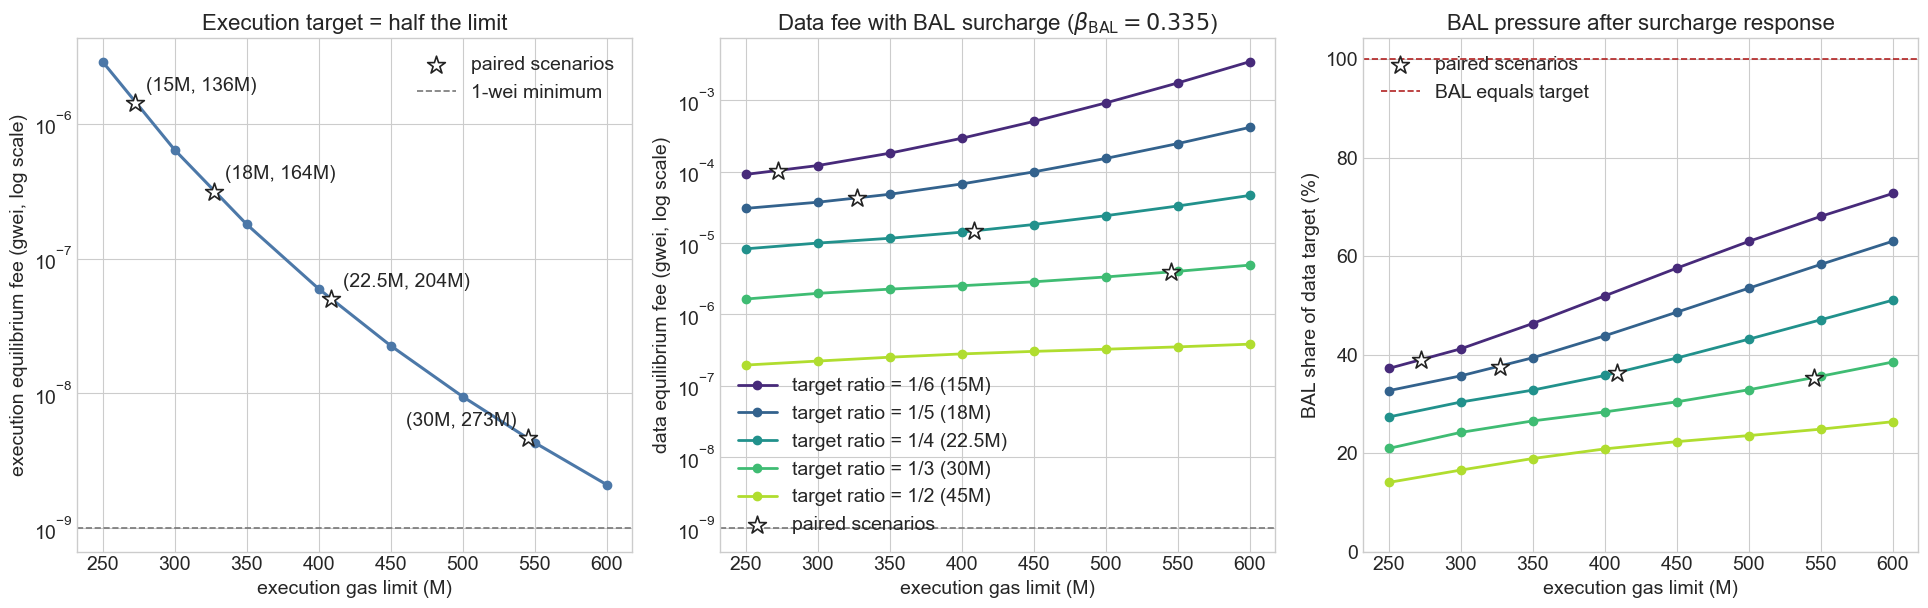

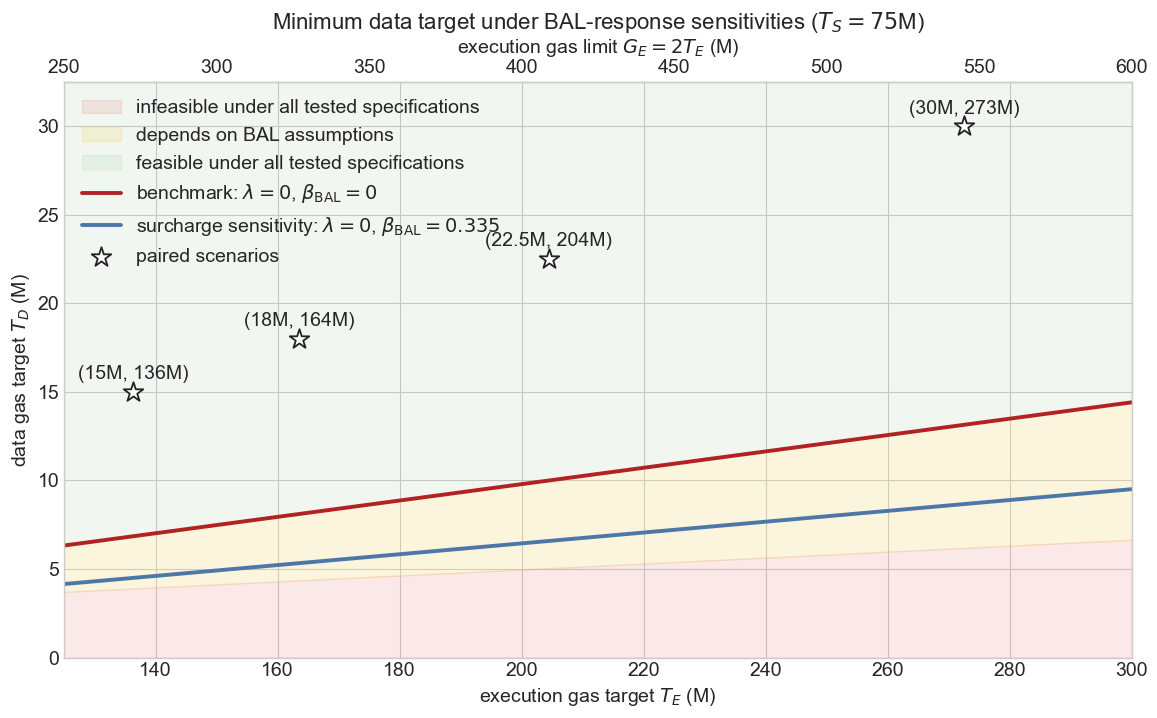

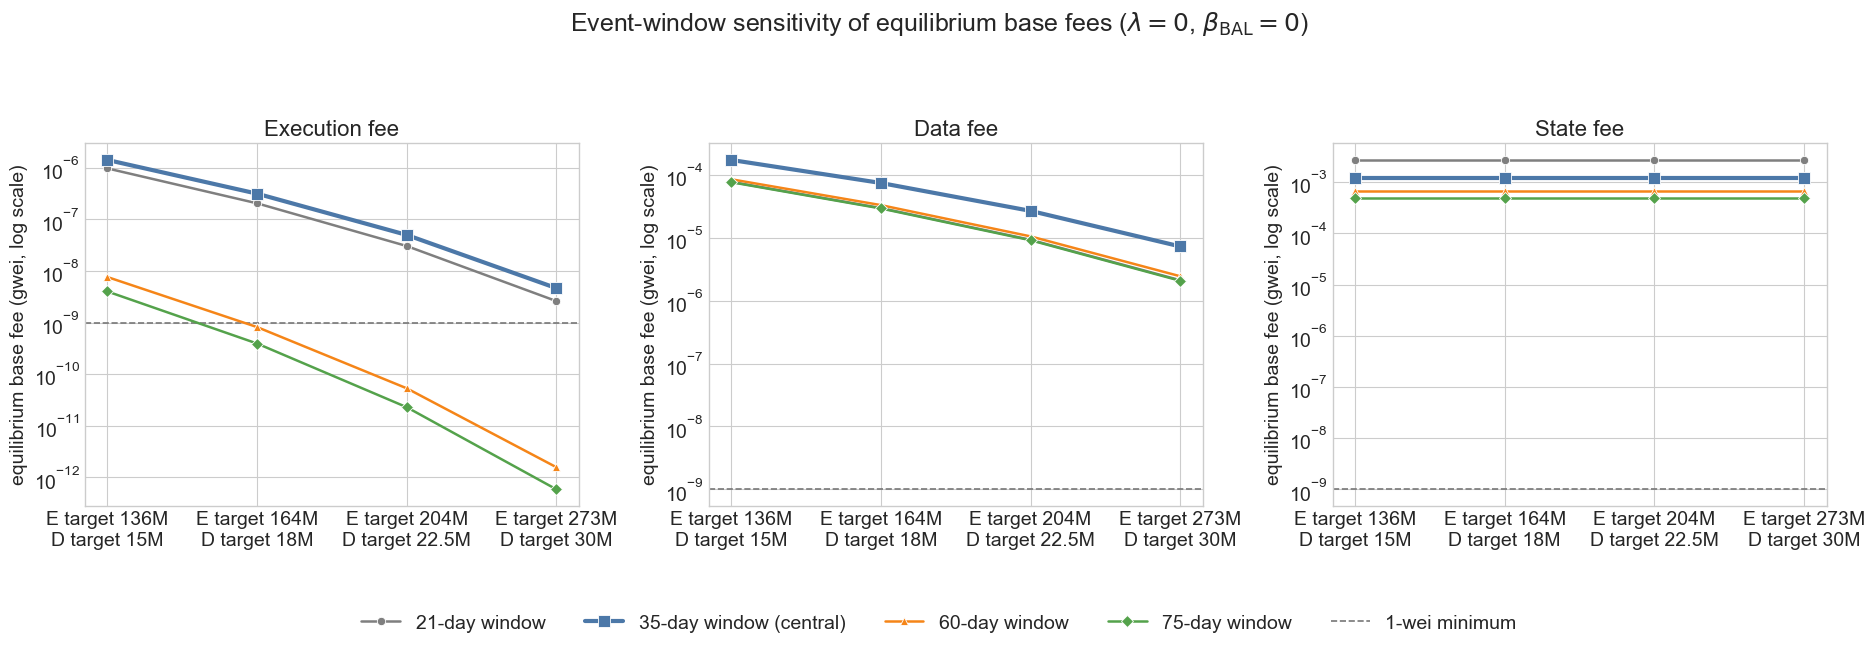

In [7]:
central_grid_execution = (
    central_grid[central_grid['resource'].eq('execution')]
    .sort_values('execution_gas_limit')
    .drop_duplicates('execution_gas_limit')
)
surcharge_grid_data = representative_surcharge_capacity_grid[
    representative_surcharge_capacity_grid['resource'].eq('data')
].copy()
paired_execution = (
    central[central['resource'].eq('execution')]
    .sort_values('execution_gas_limit')
)
paired_data = representative_surcharge_paired_data.sort_values(
    'execution_gas_limit'
)

fig, axes = plt.subplots(1, 3, figsize=(19.5, 6.3))
axes[0].plot(
    central_grid_execution['execution_gas_limit'] / 1e6,
    central_grid_execution['equilibrium_base_fee_gwei'],
    marker='o', color='#4C78A8', linewidth=2.2,
)
axes[0].scatter(
    paired_execution['execution_gas_limit'] / 1e6,
    paired_execution['equilibrium_base_fee_gwei'],
    marker='*', s=180, facecolor='white', edgecolor='#222222',
    linewidth=1.2, zorder=6, label='paired scenarios',
)
for index, row in enumerate(paired_execution.itertuples(index=False)):
    label = f'({row.data_gas_target / 1e6:g}M, {row.execution_gas_target / 1e6:.0f}M)'
    is_last = index == len(paired_execution) - 1
    axes[0].annotate(
        label,
        (row.execution_gas_limit / 1e6, row.equilibrium_base_fee_gwei),
        xytext=((-8 if is_last else 8), 9), textcoords='offset points',
        ha=('right' if is_last else 'left'), fontsize=14,
    )
axes[0].axhline(1 / GWEI, color='#777777', linestyle='--', linewidth=1.2, label='1-wei minimum')
axes[0].set_yscale('log')
axes[0].set_xlabel('execution gas limit (M)')
axes[0].set_ylabel('execution equilibrium fee (gwei, log scale)')
axes[0].set_title('Execution target = half the limit')
axes[0].legend(frameon=False)

colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(DATA_TARGET_DENOMINATORS)))
for color, denominator in zip(colors, DATA_TARGET_DENOMINATORS):
    subset = surcharge_grid_data[
        surcharge_grid_data['data_target_denominator'].eq(denominator)
    ].sort_values('execution_gas_limit')
    label = f'target ratio = 1/{denominator:g} ({subset.data_gas_target.iloc[0] / 1e6:g}M)'
    axes[1].plot(
        subset['execution_gas_limit'] / 1e6,
        subset['equilibrium_base_fee_gwei'],
        marker='o', color=color, linewidth=2, label=label,
    )
    axes[2].plot(
        subset['execution_gas_limit'] / 1e6,
        100 * subset['bal_share_of_data_target'],
        marker='o', color=color, linewidth=2, label=label,
    )
axes[1].scatter(
    paired_data['execution_gas_limit'] / 1e6,
    paired_data['equilibrium_base_fee_gwei'],
    marker='*', s=180, facecolor='white', edgecolor='#222222',
    linewidth=1.2, zorder=6, label='paired scenarios',
)
axes[2].scatter(
    paired_data['execution_gas_limit'] / 1e6,
    100 * paired_data['bal_share_of_data_target'],
    marker='*', s=180, facecolor='white', edgecolor='#222222',
    linewidth=1.2, zorder=6, label='paired scenarios',
)
axes[1].axhline(1 / GWEI, color='#777777', linestyle='--', linewidth=1.2)
axes[1].set_yscale('log')
axes[1].set_xlabel('execution gas limit (M)')
axes[1].set_ylabel('data equilibrium fee (gwei, log scale)')
axes[1].set_title(r'Data fee with BAL surcharge ($\beta_{\mathrm{BAL}}=0.335$)')
axes[1].legend(frameon=False, fontsize=14)
axes[2].axhline(100, color='#B22222', linestyle='--', linewidth=1.2, label='BAL equals target')
axes[2].set_xlabel('execution gas limit (M)')
axes[2].set_ylabel('BAL share of data target (%)')
axes[2].set_title('BAL pressure after surcharge response')
axes[2].set_ylim(bottom=0)
right_handles, right_labels = axes[2].get_legend_handles_labels()
right_legend = {label: handle for handle, label in zip(right_handles, right_labels)}
axes[2].legend(
    [right_legend['paired scenarios'], right_legend['BAL equals target']],
    ['paired scenarios', 'BAL equals target'],
    frameon=False, loc='upper left',
)
fig.tight_layout()
fig.savefig(GRID_PLOT, dpi=180, bbox_inches='tight')
plt.show()

execution_target_boundary = np.linspace(
    min(EXECUTION_LIMITS) / EXECUTION_TARGET_RATIO,
    max(EXECUTION_LIMITS) / EXECUTION_TARGET_RATIO,
    300,
)
execution_ratio_boundary = (
    execution_target_boundary / METERING_MULTIPLIERS['execution']
) / ANCHOR_QUANTITIES['execution']
access_ratio_boundary = execution_ratio_boundary ** BAL_ACCESS_RHO
state_ratio_boundary = (
    STATE_TARGET / METERING_MULTIPLIERS['state']
) / ANCHOR_QUANTITIES['state']
bal_anchor = bal_7999_total / blocks

# At the high-data-fee limit, the response of each BAL-carrying
# transaction depends only on its BAL-to-static-data ratio. Precompute
# response-weighted component shares so the boundary can be evaluated
# over a dense execution-target grid without repeatedly scanning the
# million-transaction panel.
surcharge_ratio_limit = np.divide(
    CARRIER_BAL_GAS, CARRIER_STATIC_GAS,
    out=np.full_like(CARRIER_BAL_GAS, np.inf, dtype=float),
    where=CARRIER_STATIC_GAS > 0,
)
boundary_rows = []
for beta_bal in BAL_BETA_SENSITIVITY:
    response_limit = (1.0 + surcharge_ratio_limit) ** (-beta_bal)
    response_weighted_shares = {
        'direct': np.dot(CARRIER_WEIGHT_DIRECT, response_limit) / _carrier_total_bal_gas,
        'coproduced': np.dot(CARRIER_WEIGHT_COPRODUCED, response_limit) / _carrier_total_bal_gas,
        'nonstate': np.dot(CARRIER_WEIGHT_NONSTATE, response_limit) / _carrier_total_bal_gas,
    }
    for lambda_bal in BAL_LAMBDA_SENSITIVITY:
        state_component = (
            response_weighted_shares['direct']
            + lambda_bal * response_weighted_shares['coproduced']
        )
        access_component = (
            response_weighted_shares['nonstate']
            + (1.0 - lambda_bal) * response_weighted_shares['coproduced']
        )
        minimum_data_target = bal_anchor * (
            state_ratio_boundary * state_component
            + access_ratio_boundary * access_component
        )
        for execution_target, data_target_minimum in zip(
            execution_target_boundary, minimum_data_target
        ):
            boundary_rows.append({
                'execution_gas_target': execution_target,
                'bal_coproduced_state_allocation_lambda': lambda_bal,
                'bal_surcharge_beta': beta_bal,
                'minimum_data_gas_target': data_target_minimum,
            })
boundary_envelope = pd.DataFrame(boundary_rows)
boundary_envelope.to_csv(OUT_BOUNDARY_ENVELOPE_CSV, index=False)

boundary_summary = (
    boundary_envelope.groupby('execution_gas_target')['minimum_data_gas_target']
    .agg(envelope_min='min', envelope_max='max')
    .reset_index()
)
central_boundary = boundary_envelope[
    boundary_envelope['bal_coproduced_state_allocation_lambda'].eq(0)
    & boundary_envelope['bal_surcharge_beta'].eq(0)
].sort_values('execution_gas_target')
preferred_boundary = boundary_envelope[
    boundary_envelope['bal_coproduced_state_allocation_lambda'].eq(0)
    & boundary_envelope['bal_surcharge_beta'].eq(max(BAL_BETA_SENSITIVITY))
].sort_values('execution_gas_target')
if not np.allclose(
    central_boundary['minimum_data_gas_target'],
    bal_anchor * (
        BAL_EXECUTION_RUNTIME_WEIGHT * access_ratio_boundary
        + BAL_STATE_RUNTIME_WEIGHT * state_ratio_boundary
    ),
):
    raise AssertionError('Central boundary does not reproduce the no-response BAL equation')

boundary_x = boundary_summary['execution_gas_target'].to_numpy() / 1e6
boundary_low = boundary_summary['envelope_min'].to_numpy() / 1e6
boundary_high = boundary_summary['envelope_max'].to_numpy() / 1e6
central_boundary_y = central_boundary['minimum_data_gas_target'].to_numpy() / 1e6
preferred_boundary_y = preferred_boundary['minimum_data_gas_target'].to_numpy() / 1e6
boundary_ymax = 32.5
fig, ax = plt.subplots(figsize=(11.8, 7.4))
ax.fill_between(
    boundary_x, 0, boundary_low,
    color='#E45756', alpha=0.13, label='infeasible under all tested specifications',
)
ax.fill_between(
    boundary_x, boundary_low, boundary_high,
    color='#F2CF5B', alpha=0.20, label='depends on BAL assumptions',
)
ax.fill_between(
    boundary_x, boundary_high, boundary_ymax,
    color='#54A24B', alpha=0.08, label='feasible under all tested specifications',
)
ax.plot(
    boundary_x, central_boundary_y, color='#B22222', linewidth=2.8,
    label=r'benchmark: $\lambda=0$, $\beta_{\mathrm{BAL}}=0$',
)
ax.plot(
    boundary_x, preferred_boundary_y, color='#4C78A8', linewidth=2.8,
    label=r'surcharge sensitivity: $\lambda=0$, $\beta_{\mathrm{BAL}}=0.335$',
)
ax.scatter(
    paired_data['execution_gas_target'] / 1e6,
    paired_data['data_gas_target'] / 1e6,
    marker='*', s=220, facecolor='white', edgecolor='#222222',
    linewidth=1.3, zorder=6, label='paired scenarios',
)
for row in paired_data.itertuples(index=False):
    ax.annotate(
        f'({row.data_gas_target / 1e6:g}M, {row.execution_gas_target / 1e6:.0f}M)',
        (row.execution_gas_target / 1e6, row.data_gas_target / 1e6),
        xytext=(0, 9), textcoords='offset points', ha='center', fontsize=14,
    )
ax.set_xlim(boundary_x.min(), boundary_x.max())
ax.set_ylim(0, boundary_ymax)
ax.set_xlabel(r'execution gas target $T_E$ (M)')
ax.set_ylabel(r'data gas target $T_D$ (M)')
ax.set_title(r'Minimum data target under BAL-response sensitivities ($T_S=75$M)')
secondary = ax.secondary_xaxis(
    'top', functions=(lambda target: 2 * target, lambda limit: limit / 2)
)
secondary.set_xlabel(r'execution gas limit $G_E=2T_E$ (M)')
ax.legend(frameon=False, loc='upper left', fontsize=14)
fig.tight_layout()
fig.savefig(BOUNDARY_PLOT, dpi=180, bbox_inches='tight')
plt.show()

window_rows = representative_surcharge_window_results.copy()
window_export_cols = [
    'scenario', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_limit', 'data_gas_target', 'data_target_denominator',
    'window_days', 'resource', 'gas_target', 'elasticity',
    'equilibrium_base_fee_wei_continuous', 'equilibrium_base_fee_gwei',
    'protocol_base_fee_wei', 'protocol_target_error_pct',
    'protocol_target_reachable', 'static_data_gas_at_equilibrium',
    'bal_data_gas_at_equilibrium', 'bal_share_of_data_target',
    'bal_surcharge_psi',
    'bal_target_margin_gas', 'execution_access_proxy_ratio_to_anchor',
    'reported_bal_lambda', 'reported_bal_surcharge_beta',
]
window_rows[window_export_cols].sort_values(
    ['data_gas_target', 'window_days', 'resource']
).to_csv(OUT_WINDOW_CSV, index=False)

matched_order = (
    window_rows[['scenario', 'execution_gas_target', 'data_gas_target']]
    .drop_duplicates()
    .sort_values('data_gas_target')
)
scenario_labels = [
    f'E target {row.execution_gas_target / 1e6:.0f}M\nD target {row.data_gas_target / 1e6:g}M'
    for row in matched_order.itertuples(index=False)
]
window_colors = {
    21: '#7F7F7F',
    35: '#4C78A8',
    60: '#F58518',
    75: '#54A24B',
}
window_markers = {21: 'o', 35: 's', 60: '^', 75: 'D'}

fig, axes = plt.subplots(1, 3, figsize=(19.0, 6.6), sharex=True)
x_positions = np.arange(len(matched_order))
for ax, resource in zip(axes, RESOURCES):
    resource_rows = window_rows[window_rows['resource'].eq(resource)]
    fee_by_window = (
        resource_rows.pivot(
            index='scenario', columns='window_days',
            values='equilibrium_base_fee_gwei',
        )
        .reindex(matched_order['scenario'])
    )
    for window_days in WINDOW_DAYS:
        is_central = window_days == CENTRAL_WINDOW
        ax.plot(
            x_positions,
            fee_by_window[window_days],
            color=window_colors[window_days],
            marker=window_markers[window_days],
            linewidth=3.0 if is_central else 1.8,
            markersize=8 if is_central else 6,
            markeredgecolor='white',
            markeredgewidth=0.6,
            label=(
                f'{window_days}-day window (central)'
                if is_central else f'{window_days}-day window'
            ),
            zorder=4 if is_central else 3,
        )
    ax.axhline(
        1 / GWEI, color='#777777', linestyle='--', linewidth=1.2,
        label='1-wei minimum',
    )
    ax.set_yscale('log')
    ax.set_xticks(x_positions, scenario_labels)
    ax.set_title(f'{resource.capitalize()} fee')
    ax.set_ylabel('equilibrium base fee (gwei, log scale)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=5, frameon=False, fontsize=14,
)
fig.suptitle(
    'Event-window sensitivity of equilibrium base fees '
    rf'($\lambda={WINDOW_SENSITIVITY_LAMBDA:g}$, '
    rf'$\beta_{{\mathrm{{BAL}}}}={WINDOW_SENSITIVITY_BETA:g}$)', y=0.98
)
fig.tight_layout(rect=(0, 0.13, 1, 0.92))
fig.savefig(WINDOW_PLOT, dpi=180, bbox_inches='tight')
plt.show()

## BAL allocation and surcharge sensitivity

The central specification remains $\lambda=0$ and $\Psi_{\mathrm{BAL}}=1$. The paired-scenario results are split into two figures. The allocation figure fixes $\beta_{\mathrm{BAL}}=0$ and varies $\lambda\in\{0,0.5,1\}$; the surcharge figure fixes $\lambda=0$ and varies $\beta_{\mathrm{BAL}}\in\{0,0.12,0.23,0.335\}$. Both use fee ratios and percentage-point changes in BAL share relative to the no-response benchmark. A third figure reports the two endpoint effects across the full execution-data target grid, while the final figure retains the complete $\lambda\times\beta_{\mathrm{BAL}}$ grid for the paired scenarios. All calculations hold the 35-day elasticities and each capacity scenario fixed. The positive $\beta_{\mathrm{BAL}}$ values are heuristic response cases; no separate elasticity for BAL-carrying transactions has been identified.

At $\lambda=0$, only the 11.394% of runtime BAL matched directly to state creation follows state demand. At $\lambda=1$, the 37.879% co-produced component is also allocated to state, giving a state weight of 49.273%. The surcharge $\Psi_{\mathrm{BAL}}\in(0,1]$ is one-sided: BAL bytes carried no historical data charge, so pricing them can only reduce BAL-generating activity. Larger $\beta_{\mathrm{BAL}}$ therefore lowers induced BAL and relieves the data target, the opposite of the earlier symmetric specification.

The response calculation uses the complete 6,000-block BAL-carrying-transaction panel. Each BAL-carrying transaction's non-BAL bill includes execution, EIP-8037 state gas, calldata, access lists, authorization tuples and their static EIP-8279 BAL entries, and blob-versioned hashes. The figure reports the paired capacity scenarios. Execution and state fees do not change across this grid because their independent demand curves and targets are held fixed.

,lambda,state_weight,execution_access_weight
0,0.000000,0.113937,0.886063
1,0.500000,0.303333,0.696667
2,1.000000,0.492728,0.507272


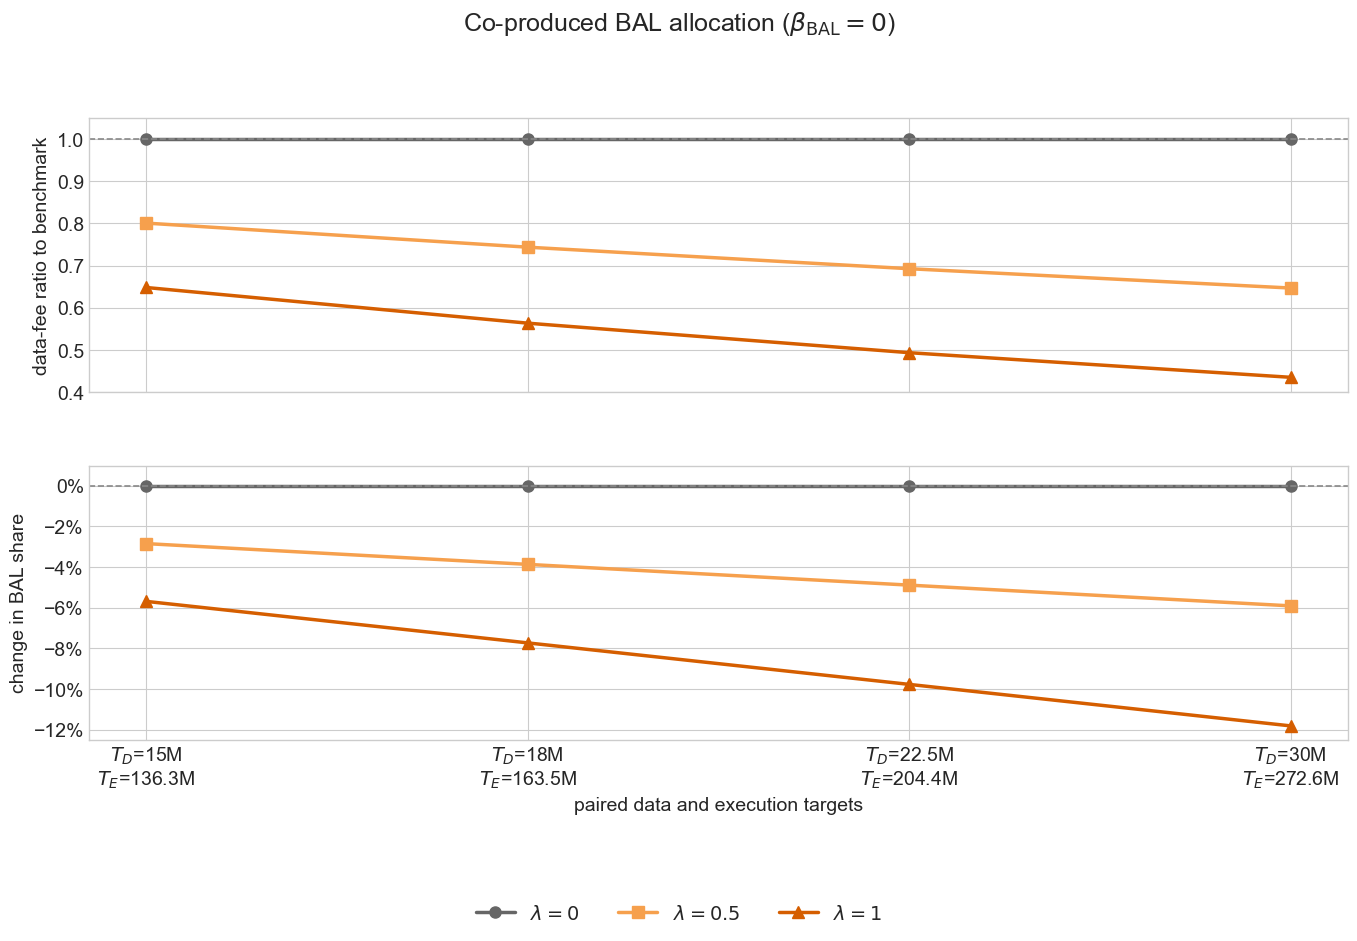

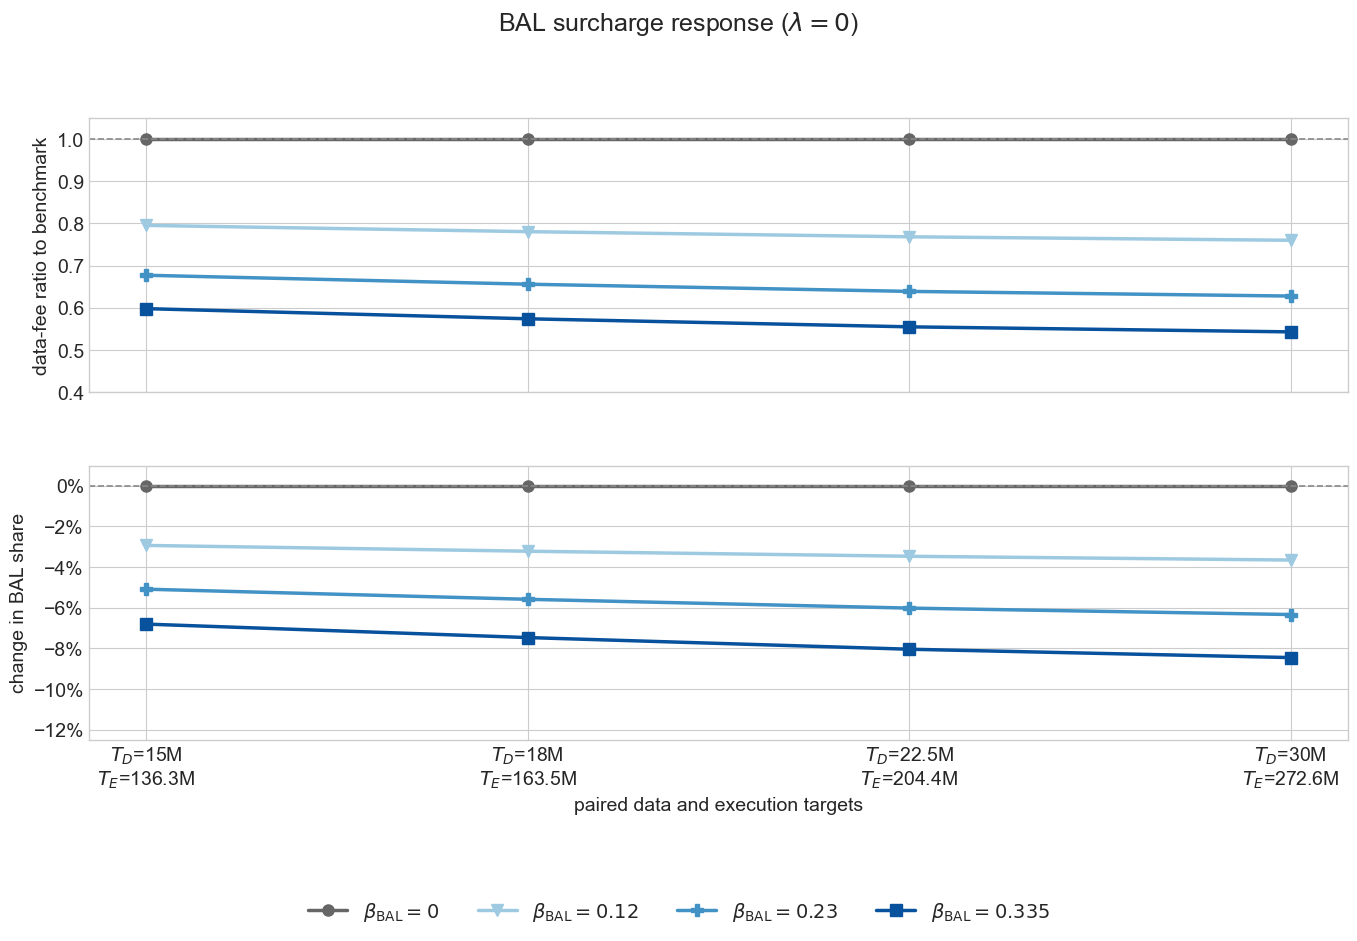

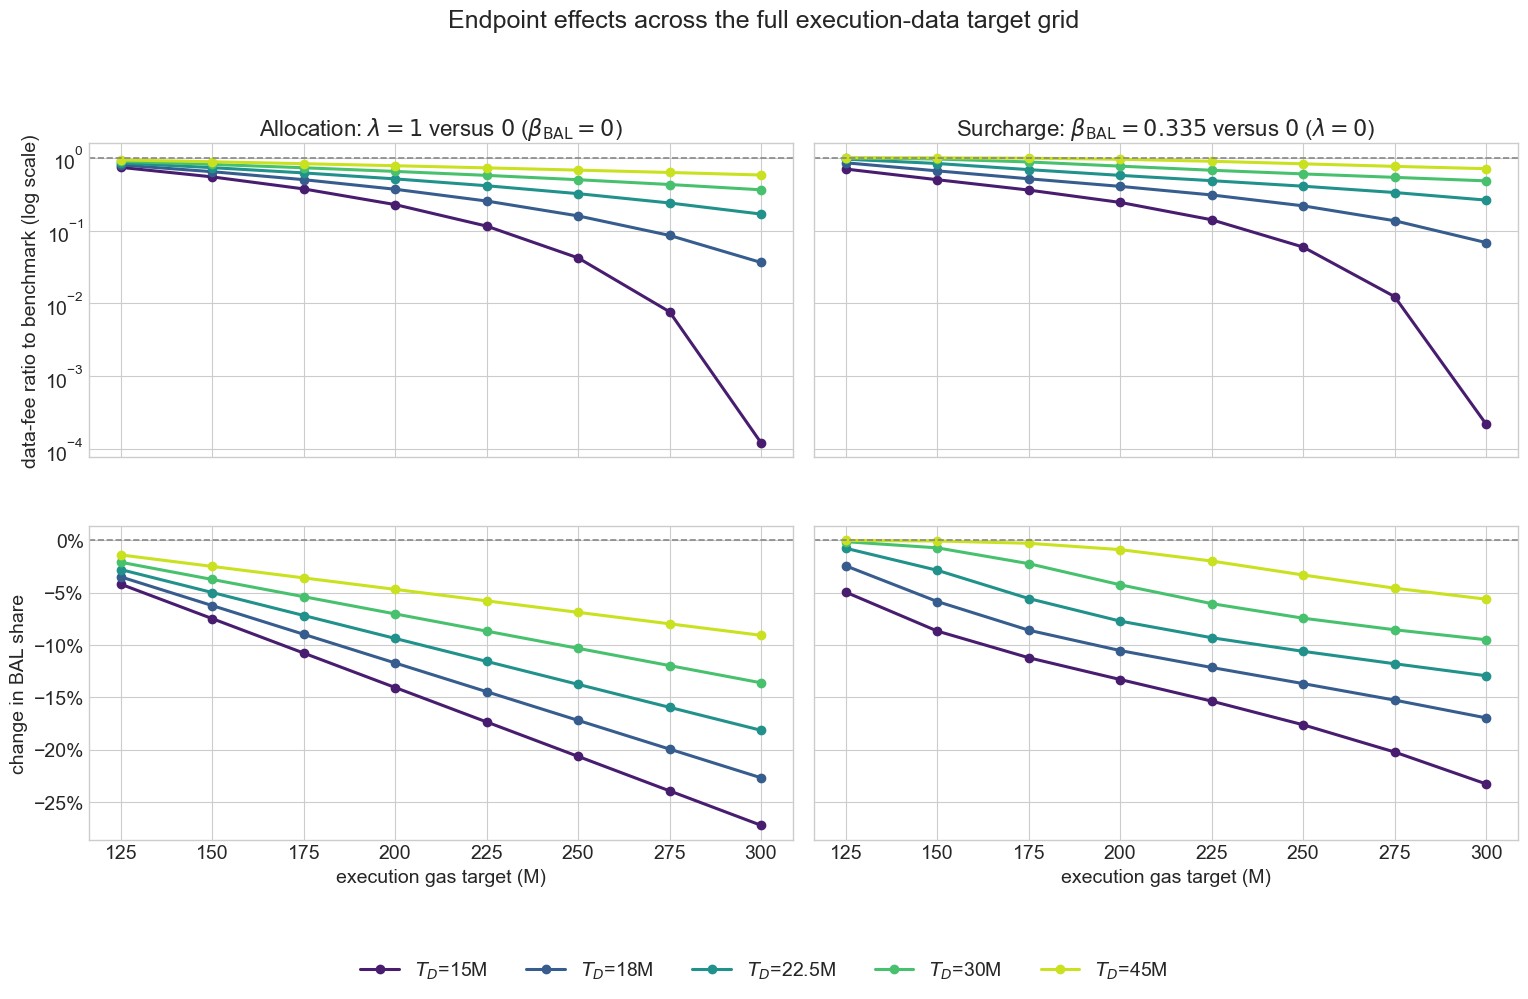

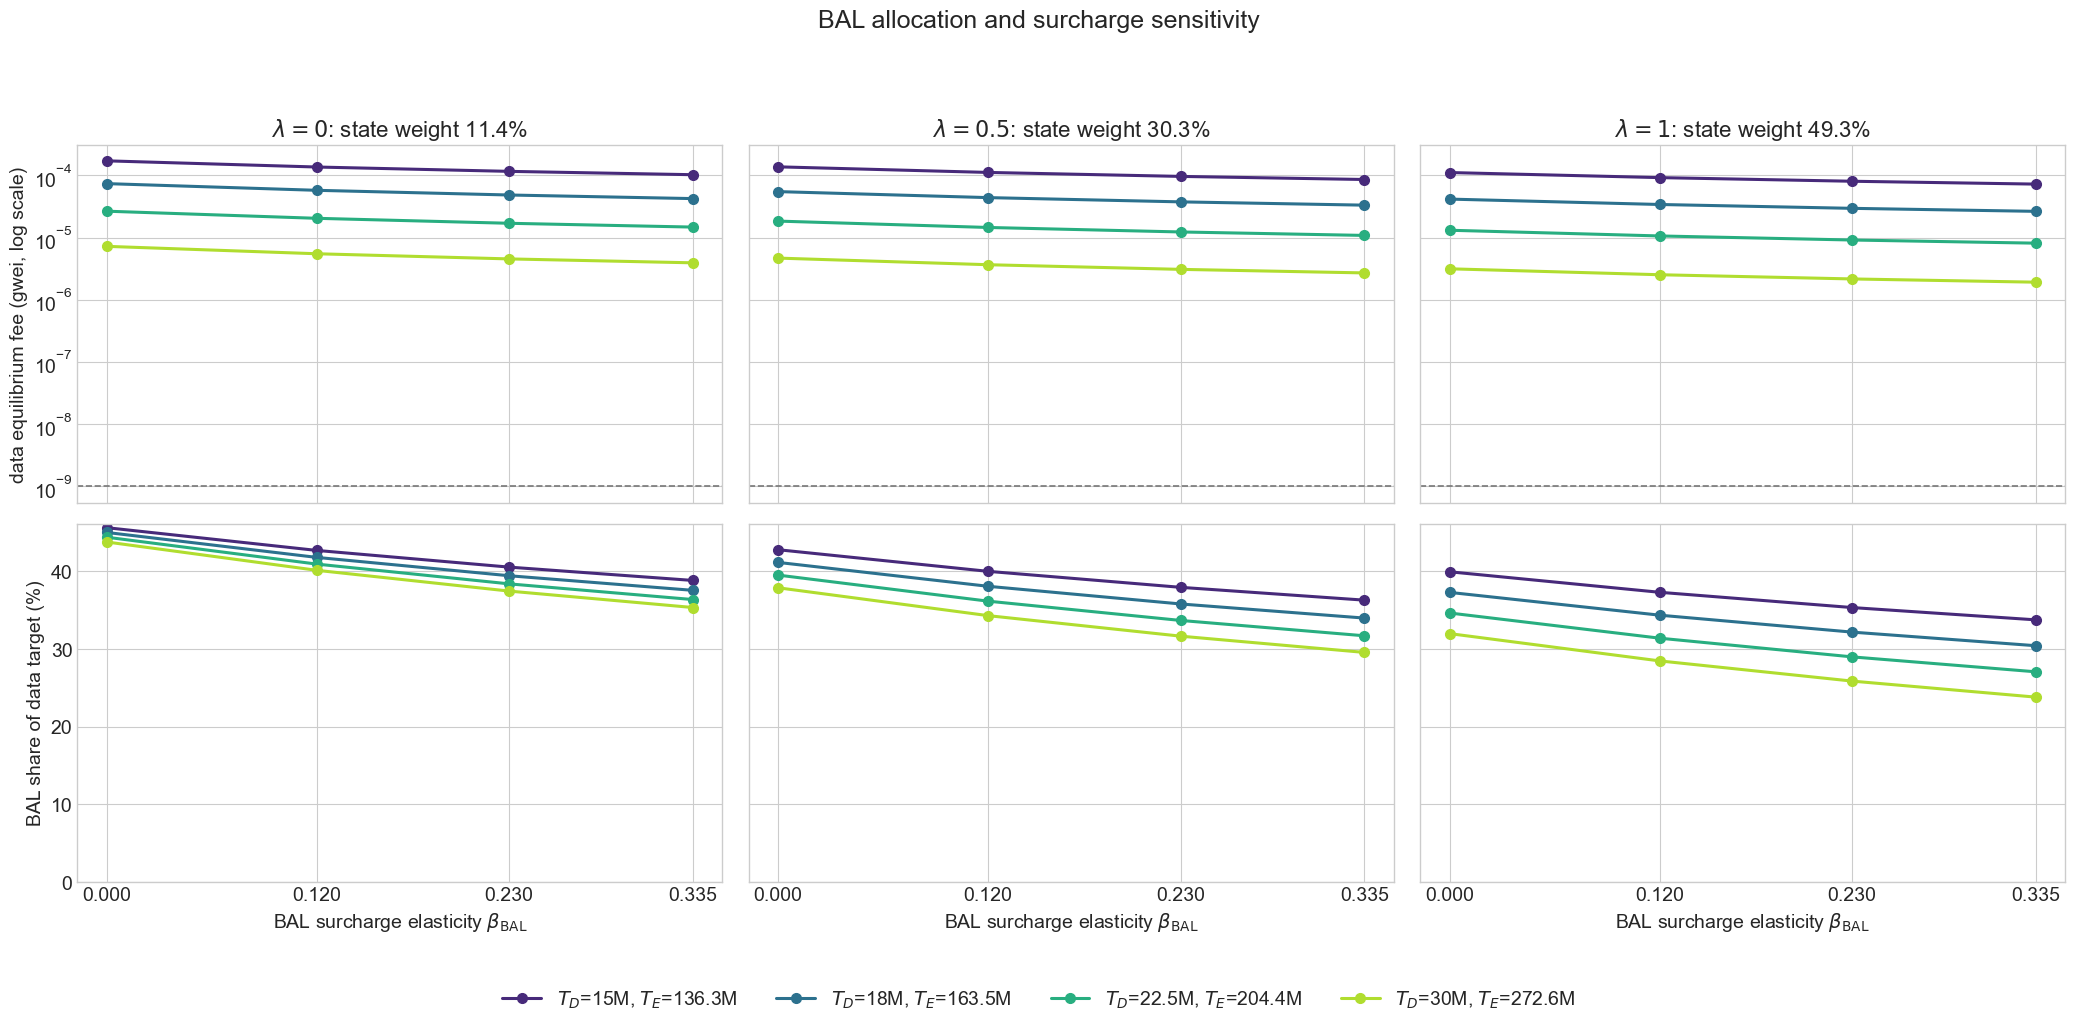

bal_surcharge_beta                                                           0.000000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.000172   
                                     0.500000                                0.000138   
                                     1.000000                                0.000111   
18000000        163540310            0.000000                                0.000074   
                                     0.500000                                0.000055   
                                     1.000000                                0.000042   
22500000        204425388            0.000000                                0.000027   
                                     0.500000                                0.000018   
                                     1.000000                                0.000013   
30000000        272567184            0.000000                                0.000007   
                                     0.500000                                0.000005   
                                     1.000000                                0.000003   

bal_surcharge_beta                                                           0.120000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.000137   
                                     0.500000                                0.000112   
                                     1.000000                                0.000092   
18000000        163540310            0.000000                                0.000058   
                                     0.500000                                0.000044   
                                     1.000000                                0.000034   
22500000        204425388            0.000000                                0.000020   
                                     0.500000                                0.000015   
                                     1.000000                                0.000011   
30000000        272567184            0.000000                                0.000006   
                                     0.500000                                0.000004   
                                     1.000000                                0.000003   

bal_surcharge_beta                                                           0.230000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.000116   
                                     0.500000                                0.000096   
                                     1.000000                                0.000081   
18000000        163540310            0.000000                                0.000048   
                                     0.500000                                0.000038   
                                     1.000000                                0.000030   
22500000        204425388            0.000000                                0.000017   
                                     0.500000                                0.000012   
                                     1.000000                                0.000009   
30000000        272567184            0.000000                                0.000005   
                                     0.500000                                0.000003   
                                     1.000000                                0.000002   

bal_surcharge_beta                                                           0.335000  
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda            
15000000        136283592            0.000000                                0.0001

bal_surcharge_beta                                                           0.000000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                1.000000   
                                     0.500000                                1.000000   
                                     1.000000                                1.000000   
18000000        163540310            0.000000                                1.000000   
                                     0.500000                                1.000000   
                                     1.000000                                1.000000   
22500000        204425388            0.000000                                1.000000   
                                     0.500000                                1.000000   
                                     1.000000                                1.000000   
30000000        272567184            0.000000                                1.000000   
                                     0.500000                                1.000000   
                                     1.000000                                1.000000   

bal_surcharge_beta                                                           0.120000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.935785   
                                     0.500000                                0.934880   
                                     1.000000                                0.933823   
18000000        163540310            0.000000                                0.928589   
                                     0.500000                                0.925199   
                                     1.000000                                0.921250   
22500000        204425388            0.000000                                0.922007   
                                     0.500000                                0.914992   
                                     1.000000                                0.906306   
30000000        272567184            0.000000                                0.916650   
                                     0.500000                                0.905270   
                                     1.000000                                0.890005   

bal_surcharge_beta                                                           0.230000  \
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda             
15000000        136283592            0.000000                                0.888609   
                                     0.500000                                0.886743   
                                     1.000000                                0.884584   
18000000        163540310            0.000000                                0.876040   
                                     0.500000                                0.869886   
                                     1.000000                                0.862704   
22500000        204425388            0.000000                                0.864572   
                                     0.500000                                0.852146   
                                     1.000000                                0.836747   
30000000        272567184            0.000000                                0.855445   
                                     0.500000                                0.835461   
                                     1.000000                                0.808644   

bal_surcharge_beta                                                           0.335000  
data_gas_target execution_gas_target bal_coproduced_state_allocation_lambda            
15000000        136283592            0.000000                                0.8509

In [8]:
lambda_weight_table = pd.DataFrame([
    {
        'lambda': lambda_bal,
        'state_weight': (
            BAL_DIRECT_STATE_WEIGHT
            + lambda_bal * BAL_COPRODUCED_RUNTIME_WEIGHT
        ),
        'execution_access_weight': (
            BAL_NONSTATE_RUNTIME_WEIGHT
            + (1 - lambda_bal) * BAL_COPRODUCED_RUNTIME_WEIGHT
        ),
    }
    for lambda_bal in BAL_LAMBDA_SENSITIVITY
])
display(lambda_weight_table)

paired_bal_sensitivity = bal_sensitivity[
    bal_sensitivity['empirically_matched']
].copy()
paired_scenario_order = (
    paired_bal_sensitivity[[
        'scenario', 'execution_gas_target', 'data_gas_target'
    ]]
    .drop_duplicates()
    .sort_values('data_gas_target')
)
scenario_colors = dict(zip(
    paired_scenario_order['scenario'],
    plt.cm.viridis(np.linspace(0.12, 0.88, len(paired_scenario_order))),
))

named_specifications = pd.DataFrame([
    {'specification': 'No-response benchmark', 'lambda_bal': 0.0, 'beta_bal': 0.0},
    {'specification': 'Mild surcharge response', 'lambda_bal': 0.0, 'beta_bal': 0.12},
    {'specification': 'Moderate surcharge response', 'lambda_bal': 0.0, 'beta_bal': 0.23},
    {'specification': 'Strong surcharge response', 'lambda_bal': 0.0, 'beta_bal': 0.335},
    {'specification': 'Midpoint allocation sensitivity', 'lambda_bal': 0.5, 'beta_bal': 0.0},
    {'specification': 'Midpoint allocation plus mild surcharge', 'lambda_bal': 0.5, 'beta_bal': 0.12},
    {'specification': 'Midpoint allocation plus moderate surcharge', 'lambda_bal': 0.5, 'beta_bal': 0.23},
    {'specification': 'Midpoint allocation plus strong surcharge', 'lambda_bal': 0.5, 'beta_bal': 0.335},
    {'specification': 'Allocation sensitivity', 'lambda_bal': 1.0, 'beta_bal': 0.0},
    {'specification': 'Full allocation plus mild surcharge', 'lambda_bal': 1.0, 'beta_bal': 0.12},
    {'specification': 'Full allocation plus moderate surcharge', 'lambda_bal': 1.0, 'beta_bal': 0.23},
    {'specification': 'Combined sensitivity', 'lambda_bal': 1.0, 'beta_bal': 0.335},
])
named_rows = []
for spec_row in named_specifications.itertuples(index=False):
    subset = paired_bal_sensitivity[
        paired_bal_sensitivity['bal_coproduced_state_allocation_lambda'].eq(spec_row.lambda_bal)
        & paired_bal_sensitivity['bal_surcharge_beta'].eq(spec_row.beta_bal)
    ].copy()
    subset['specification'] = spec_row.specification
    named_rows.append(subset)
named_bal_sensitivity = pd.concat(named_rows, ignore_index=True)
benchmark_rows = (
    named_bal_sensitivity[
        named_bal_sensitivity['specification'].eq('No-response benchmark')
    ][['scenario', 'equilibrium_base_fee_gwei', 'bal_share_of_data_target']]
    .rename(columns={
        'equilibrium_base_fee_gwei': 'benchmark_data_fee_gwei',
        'bal_share_of_data_target': 'benchmark_bal_share',
    })
)
named_bal_sensitivity = named_bal_sensitivity.merge(
    benchmark_rows, on='scenario', how='left', validate='many_to_one'
)
named_bal_sensitivity['data_fee_ratio_to_benchmark'] = (
    named_bal_sensitivity['equilibrium_base_fee_gwei']
    / named_bal_sensitivity['benchmark_data_fee_gwei']
)
named_bal_sensitivity['bal_share_change_pp'] = 100 * (
    named_bal_sensitivity['bal_share_of_data_target']
    - named_bal_sensitivity['benchmark_bal_share']
)
named_bal_sensitivity.to_csv(OUT_NAMED_BAL_SENSITIVITY_CSV, index=False)
if not np.allclose(
    named_bal_sensitivity.loc[
        named_bal_sensitivity['specification'].eq('No-response benchmark'),
        'data_fee_ratio_to_benchmark',
    ],
    1.0,
):
    raise AssertionError('Named sensitivity benchmark fee ratio must equal one')

paired_relative = paired_bal_sensitivity.merge(
    benchmark_rows, on='scenario', how='left', validate='many_to_one'
)
paired_relative['data_fee_ratio_to_benchmark'] = (
    paired_relative['equilibrium_base_fee_gwei']
    / paired_relative['benchmark_data_fee_gwei']
)
paired_relative['bal_share_change_pp'] = 100 * (
    paired_relative['bal_share_of_data_target']
    - paired_relative['benchmark_bal_share']
)

paired_x = np.arange(len(paired_scenario_order))
paired_xlabels = [
    f'$T_D$={row.data_gas_target / 1e6:g}M\n$T_E$={row.execution_gas_target / 1e6:.1f}M'
    for row in paired_scenario_order.itertuples(index=False)
]

def plot_paired_relative_effects(specifications, title, output_path, fee_ylim, share_ylim):
    fig, axes = plt.subplots(2, 1, figsize=(13.8, 9.6), sharex=True)
    for spec in specifications:
        subset = (
            paired_relative[
                paired_relative['bal_coproduced_state_allocation_lambda'].eq(spec['lambda'])
                & paired_relative['bal_surcharge_beta'].eq(spec['beta'])
            ]
            .set_index('scenario')
            .reindex(paired_scenario_order['scenario'])
        )
        line_kwargs = {
            'color': spec['color'],
            'marker': spec['marker'],
            'linewidth': 2.5,
            'markersize': 8,
            'label': spec['label'],
        }
        axes[0].plot(paired_x, subset['data_fee_ratio_to_benchmark'], **line_kwargs)
        axes[1].plot(paired_x, subset['bal_share_change_pp'], **line_kwargs)
    axes[0].axhline(1, color='#888888', linestyle='--', linewidth=1.2)
    axes[1].axhline(0, color='#888888', linestyle='--', linewidth=1.2)
    axes[0].set_ylabel('data-fee ratio to benchmark')
    axes[1].set_ylabel('change in BAL share')
    axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    axes[1].set_xticks(paired_x, paired_xlabels)
    axes[1].set_xlabel('paired data and execution targets')
    axes[0].set_ylim(*fee_ylim)
    axes[1].set_ylim(*share_ylim)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01),
        ncol=len(specifications), frameon=False, fontsize=14,
    )
    fig.suptitle(title, y=0.98)
    fig.tight_layout(rect=(0, 0.12, 1, 0.94), h_pad=3.2)
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()

allocation_specifications = [
    {'lambda': 0.0, 'beta': 0.0, 'label': r'$\lambda=0$',
     'color': '#666666', 'marker': 'o'},
    {'lambda': 0.5, 'beta': 0.0, 'label': r'$\lambda=0.5$',
     'color': '#F6A04D', 'marker': 's'},
    {'lambda': 1.0, 'beta': 0.0, 'label': r'$\lambda=1$',
     'color': '#D55E00', 'marker': '^'},
]
plot_paired_relative_effects(
    allocation_specifications,
    r'Co-produced BAL allocation ($\beta_{\mathrm{BAL}}=0$)',
    BAL_ALLOCATION_PLOT,
    fee_ylim=(0.4, 1.05),
    share_ylim=(-12.5, 1.0),
)

surcharge_specifications = [
    {'lambda': 0.0, 'beta': 0.0, 'label': r'$\beta_{\mathrm{BAL}}=0$',
     'color': '#666666', 'marker': 'o'},
    {'lambda': 0.0, 'beta': 0.12, 'label': r'$\beta_{\mathrm{BAL}}=0.12$',
     'color': '#9ECAE1', 'marker': 'v'},
    {'lambda': 0.0, 'beta': 0.23, 'label': r'$\beta_{\mathrm{BAL}}=0.23$',
     'color': '#4292C6', 'marker': 'P'},
    {'lambda': 0.0, 'beta': 0.335, 'label': r'$\beta_{\mathrm{BAL}}=0.335$',
     'color': '#08519C', 'marker': 's'},
]
plot_paired_relative_effects(
    surcharge_specifications,
    r'BAL surcharge response ($\lambda=0$)',
    BAL_SURCHARGE_PLOT,
    fee_ylim=(0.4, 1.05),
    share_ylim=(-12.5, 1.0),
)

off_path_sensitivity = bal_sensitivity[
    bal_sensitivity['scenario_family'].eq('off_path_grid')
].copy()
off_path_benchmark = (
    off_path_sensitivity[
        off_path_sensitivity['bal_coproduced_state_allocation_lambda'].eq(0)
        & off_path_sensitivity['bal_surcharge_beta'].eq(0)
    ][['scenario', 'equilibrium_base_fee_gwei', 'bal_share_of_data_target']]
    .rename(columns={
        'equilibrium_base_fee_gwei': 'benchmark_data_fee_gwei',
        'bal_share_of_data_target': 'benchmark_bal_share',
    })
)
off_path_relative = off_path_sensitivity.merge(
    off_path_benchmark, on='scenario', how='left', validate='many_to_one'
)
off_path_relative['data_fee_ratio_to_benchmark'] = (
    off_path_relative['equilibrium_base_fee_gwei']
    / off_path_relative['benchmark_data_fee_gwei']
)
off_path_relative['bal_share_change_pp'] = 100 * (
    off_path_relative['bal_share_of_data_target']
    - off_path_relative['benchmark_bal_share']
)

capacity_effects = [
    {'title': r'Allocation: $\lambda=1$ versus $0$ ($\beta_{\mathrm{BAL}}=0$)',
     'lambda': 1.0, 'beta': 0.0},
    {'title': r'Surcharge: $\beta_{\mathrm{BAL}}=0.335$ versus $0$ ($\lambda=0$)',
     'lambda': 0.0, 'beta': 0.335},
]
data_targets = sorted(off_path_relative['data_gas_target'].unique())
data_target_colors = dict(zip(
    data_targets, plt.cm.viridis(np.linspace(0.08, 0.92, len(data_targets)))
))
fig, axes = plt.subplots(2, 2, figsize=(15.5, 10.2), sharex='col', sharey='row')
for column, effect in enumerate(capacity_effects):
    effect_rows = off_path_relative[
        off_path_relative['bal_coproduced_state_allocation_lambda'].eq(effect['lambda'])
        & off_path_relative['bal_surcharge_beta'].eq(effect['beta'])
    ]
    for data_target in data_targets:
        subset = effect_rows[
            effect_rows['data_gas_target'].eq(data_target)
        ].sort_values('execution_gas_target')
        label = f'$T_D$={data_target / 1e6:g}M'
        line_kwargs = {
            'marker': 'o', 'linewidth': 2.2, 'markersize': 6,
            'color': data_target_colors[data_target], 'label': label,
        }
        x_target = subset['execution_gas_target'] / 1e6
        axes[0, column].plot(
            x_target, subset['data_fee_ratio_to_benchmark'], **line_kwargs
        )
        axes[1, column].plot(
            x_target, subset['bal_share_change_pp'], **line_kwargs
        )
    axes[0, column].set_title(effect['title'])
    axes[0, column].set_yscale('log')
    axes[0, column].axhline(1, color='#888888', linestyle='--', linewidth=1.2)
    axes[1, column].axhline(0, color='#888888', linestyle='--', linewidth=1.2)
    axes[1, column].set_xlabel('execution gas target (M)')
axes[0, 0].set_ylabel('data-fee ratio to benchmark (log scale)')
axes[1, 0].set_ylabel('change in BAL share')
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=len(data_targets), frameon=False, fontsize=14,
)
fig.suptitle('Endpoint effects across the full execution-data target grid', y=0.98)
fig.tight_layout(rect=(0, 0.10, 1, 0.94), h_pad=3.2)
fig.savefig(BAL_CAPACITY_EFFECTS_PLOT, dpi=180, bbox_inches='tight')
plt.show()

n_lambda = len(BAL_LAMBDA_SENSITIVITY)
fig, axes = plt.subplots(
    2, n_lambda, figsize=(7.0 * n_lambda, 10.5), sharex='col', sharey='row'
)
for column, lambda_bal in enumerate(BAL_LAMBDA_SENSITIVITY):
    lambda_rows = paired_bal_sensitivity[
        paired_bal_sensitivity['bal_coproduced_state_allocation_lambda'].eq(lambda_bal)
    ]
    for scenario_row in paired_scenario_order.itertuples(index=False):
        subset = lambda_rows[
            lambda_rows['scenario'].eq(scenario_row.scenario)
        ].sort_values('bal_surcharge_beta')
        label = (
            f'$T_D$={scenario_row.data_gas_target / 1e6:g}M, '
            f'$T_E$={scenario_row.execution_gas_target / 1e6:.1f}M'
        )
        axes[0, column].plot(
            subset['bal_surcharge_beta'],
            subset['equilibrium_base_fee_gwei'],
            marker='o', linewidth=2.2, markersize=7,
            color=scenario_colors[scenario_row.scenario], label=label,
        )
        axes[1, column].plot(
            subset['bal_surcharge_beta'],
            100 * subset['bal_share_of_data_target'],
            marker='o', linewidth=2.2, markersize=7,
            color=scenario_colors[scenario_row.scenario], label=label,
        )

    state_weight = lambda_weight_table.loc[
        lambda_weight_table['lambda'].eq(lambda_bal), 'state_weight'
    ].iloc[0]
    axes[0, column].set_title(
        f'$\\lambda={lambda_bal:g}$: state weight {100 * state_weight:.1f}%'
    )
    axes[0, column].set_yscale('log')
    axes[0, column].axhline(
        1 / GWEI, color='#777777', linestyle='--', linewidth=1.2,
    )
    axes[1, column].set_xlabel(r'BAL surcharge elasticity $\beta_{\mathrm{BAL}}$')
    axes[1, column].set_xticks(BAL_BETA_SENSITIVITY)
    axes[1, column].set_ylim(bottom=0)

axes[0, 0].set_ylabel('data equilibrium fee (gwei, log scale)')
axes[1, 0].set_ylabel('BAL share of data target (%)')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=4, frameon=False, fontsize=14,
)
fig.suptitle('BAL allocation and surcharge sensitivity', y=0.98)
fig.tight_layout(rect=(0, 0.08, 1, 0.94))
fig.savefig(BAL_SENSITIVITY_PLOT, dpi=180, bbox_inches='tight')
plt.show()

paired_fee_grid = paired_bal_sensitivity.pivot_table(
    index=[
        'data_gas_target', 'execution_gas_target',
        'bal_coproduced_state_allocation_lambda',
    ],
    columns='bal_surcharge_beta',
    values='equilibrium_base_fee_gwei',
).sort_index()
display(paired_fee_grid)

paired_psi_grid = paired_bal_sensitivity.pivot_table(
    index=[
        'data_gas_target', 'execution_gas_target',
        'bal_coproduced_state_allocation_lambda',
    ],
    columns='bal_surcharge_beta',
    values='bal_surcharge_psi',
).sort_index()
display(paired_psi_grid)


## Demand adequacy and BAL pressure

The isoelastic equations produce a model-implied execution fee, but the protocol cannot charge less than one wei. If the equilibrium fee is below one wei, demand at the protocol minimum is still below the target. That is the clearest model-based warning that the proposed execution target may exceed demand under the estimated curve.

This is not a forecast that demand will fail to grow. It shows how far the capacity scenarios extrapolate from the observed anchor and where the protocol minimum prevents exact target clearing.

For data, the corresponding diagnostic is the remaining target space after induced BAL:

$$
T_D-B^*.
$$

The closer this margin is to zero, the more the data equilibrium is determined by BAL rather than static transaction data.

In [9]:
execution_adequacy = central_grid_execution[[
    'execution_gas_limit', 'execution_gas_target',
    'target_to_metered_anchor_ratio', 'equilibrium_base_fee_wei_continuous',
    'protocol_base_fee_wei', 'demand_at_minimum_fee',
    'demand_shortfall_at_minimum_fee', 'protocol_target_reachable',
]].sort_values('execution_gas_limit')
execution_adequacy.to_csv(OUT_DEMAND_ADEQUACY_CSV, index=False)
display(execution_adequacy)

matched_data = central[
    central['resource'].eq('data')
][[
    'scenario', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_target', 'equilibrium_base_fee_gwei',
    'static_data_gas_at_equilibrium', 'bal_data_gas_at_equilibrium',
    'bal_share_of_data_target', 'bal_target_margin_gas',
    'equilibrium_exists', 'protocol_target_reachable',
]].sort_values('data_gas_target')
display(matched_data)

,execution_gas_limit,execution_gas_target,target_to_metered_anchor_ratio,equilibrium_base_fee_wei_continuous,protocol_base_fee_wei,demand_at_minimum_fee,demand_shortfall_at_minimum_fee,protocol_target_reachable
132,250000000,125000000,3.394827,"2,890.816397",2891,"328,281,194.052292",0.000000,True
159,300000000,150000000,4.073793,641.936780,642,"328,281,194.052292",0.000000,True
162,350000000,175000000,4.752758,179.863068,180,"328,281,194.052292",0.000000,True
186,400000000,200000000,5.431723,59.744948,60,"328,281,194.052292",0.000000,True
192,450000000,225000000,6.110689,22.600085,23,"328,281,194.052292",0.000000,True
219,500000000,250000000,6.789654,9.472121,9,"328,281,194.052292",0.000000,True
222,550000000,275000000,7.468620,4.313300,4,"328,281,194.052292",0.000000,True
246,600000000,300000000,8.147585,2.103386,2,"328,281,194.052292",0.000000,True


,scenario,execution_gas_limit,execution_gas_target,data_gas_target,equilibrium_base_fee_gwei,static_data_gas_at_equilibrium,bal_data_gas_at_equilibrium,bal_share_of_data_target,bal_target_margin_gas,equilibrium_exists,protocol_target_reachable
253,matched_E272.6_D90_T1of6_S75,272567184,136283592,15000000,0.000172,"8,153,334.171378","6,846,665.828622",0.456444,"8,153,334.171378",True,True
256,matched_E327.1_D90_T1of5_S75,327080621,163540310,18000000,0.000074,"9,894,572.949158","8,105,427.050842",0.450302,"9,894,572.949158",True,True
259,matched_E408.9_D90_T1of4_S75,408850776,204425388,22500000,0.000027,"12,506,431.069647","9,993,568.930353",0.444159,"12,506,431.069647",True,True
262,matched_E545.1_D90_T1of3_S75,545134368,272567184,30000000,0.000007,"16,859,527.967916","13,140,472.032084",0.438016,"16,859,527.967916",True,True


## Interpretation

- Full EIP-7999 has an equilibrium fee vector: execution and state clear independent targets, while the data fee clears static data plus BAL induced by the execution and state targets.
- The empirically anchored capacity combinations preserve the observed metered data/execution ratio. They form the main comparison; the full 8-by-5 grid tests imbalanced capacity choices.
- The 90M metered data limit is held fixed as a scenario input. It is not interpreted as a physical payload bound because runtime-metered BAL bytes differ from final BAL RLP bytes.
- With $\Psi_{\mathrm{BAL}}=1$, raising the data fee does not reduce BAL at all. High execution targets can therefore leave little room for static data when the data target is low.
- The surcharge is one-sided: BAL bytes were never charged a data fee historically, so pricing them can only reduce BAL-generating activity. Larger $\beta_{\mathrm{BAL}}$ therefore lowers both BAL's share of the data target and the equilibrium data fee, and it pushes the feasibility boundary outward. Setting $\lambda=1$ also reduces BAL in this capacity range because it shifts the co-produced component from the more rapidly scaled execution/access proxy to the fixed state target.
- Execution limits up to 600M require substantial extrapolation from the observed execution anchor. Scenarios whose equilibrium execution fee falls below one wei cannot clear their target under the protocol minimum and should be interpreted as demand-adequacy warnings.
- The notebook solves the reserve-free equilibrium. Reserve-dominated equilibria require a specified blob-fee path or reserve scenario; limit hits, volatility, and shock recovery require the dynamic replay.